# 12 · Synchronization quality report

Signal samples and timestamp coverage are read from the processed XDF files in the publication root. IDUN raw EEG is the only raw-signal exception, used for the before/after EEG comparison. Saved QC tables provide mapping status, fit diagnostics, coefficients, and support intervals. All reporting functions are defined in this notebook.


In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyxdf
from IPython.display import Image, display

PROJECT_ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                    if (p / 'helpers/project_config.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from helpers.project_config import load_project_config

CONFIG = load_project_config(PROJECT_ROOT / 'ImBrAid/config.json')
OUTPUT_DIR = CONFIG.path('files', 'et_lsl_alignment_csv').parent / '12_sync_quality_report'
OVERWRITE = True
PROCESSED_XDF_ROOT = CONFIG.path('paths', 'publication_root') / 'XDF'
_XDF_HEADER_CACHE = {}
INCLUDE_PUPIL_EXAMPLES = True  # Reads ET and Eyeball streams from processed XDFs.
# QC metadata: mapping status, fit coefficients, support bounds and issue records.
QC_TABLE_PATHS = {key: CONFIG.path('files', key) for key in CONFIG.values['files']
               if key.endswith('_alignment_csv') or key.endswith('_issues_csv')}
QC_TABLES = {key: pd.read_csv(p, dtype={k: str for k in ['project', 'pid', 'participant', 'visit', 'segment_id']},
                           keep_default_na=False) for key, p in QC_TABLE_PATHS.items()}
print('Output directory:', OUTPUT_DIR)


Output directory: E:\test\SyncQuality\12_sync_quality_report


## Prepare records and coverage

The overview covers all records in the saved mapping tables. Timestamp coverage is calculated from the processed XDF streams.


In [2]:
def processed_xdf_path(record):
    return PROCESSED_XDF_ROOT / f"{record['pid']}_{record['visit']}_synchronized.xdf"


def read_processed_xdf(record, requested):
    """Read selected channels while preserving the added streams' exact LSL timestamps."""
    path = processed_xdf_path(record)
    key = (str(path), path.stat().st_mtime_ns)
    if key not in _XDF_HEADER_CACHE:
        _XDF_HEADER_CACHE[key] = pyxdf.resolve_streams(str(path))
    selected = [s for s in _XDF_HEADER_CACHE[key] if s['name'] in requested]
    if not selected:
        return {}
    columns_by_id = {}
    def take_columns(values, timestamps, header, stream_id):
        name = header['info']['name'][0]
        if stream_id not in columns_by_id:
            channels = header['info']['desc'][0]['channels'][0]['channel']
            labels = [c['label'][0] for c in channels]
            columns = [c for c in requested[name] if c in labels]
            columns_by_id[stream_id] = (columns, [labels.index(c) for c in columns])
        columns, indices = columns_by_id[stream_id]
        return np.asarray(values)[:, indices].copy(), timestamps, header
    streams, _ = pyxdf.load_xdf(
        str(path), select_streams=[s['stream_id'] for s in selected], on_chunk=take_columns,
        synchronize_clocks=False, dejitter_timestamps=False, verbose=False)
    result = {}
    for stream in streams:
        name = stream['info']['name'][0]
        columns = columns_by_id.get(stream['info']['stream_id'], ([], []))[0]
        times = np.asarray(stream['time_stamps'], dtype=float)
        values = np.asarray(stream['time_series']) if len(times) else np.empty((0, len(columns)))
        if set(columns) != set(requested[name]):
            raise ValueError(f"{path.name}: missing requested channels in {name}")
        if name in result:
            raise ValueError(f"{path.name}: more than one {name} stream")
        result[name] = pd.DataFrame(values, columns=columns)
        result[name].insert(0, '__lsl_time_s', times)
    return result


# Mapping name -> (QC metadata table, corresponding processed XDF stream).
PAIR_QC_TABLES = {
    'et_lsl': ('et_lsl_alignment_csv', 'ET'),
    'eyeball_et': ('et_eyeball_alignment_csv', 'Eyeball'),
    'idun_lsl': ('idun_lsl_alignment_csv', 'IDUN'),
    'driver_et': ('driver_et_alignment_csv', 'DriverVideo'),
}
IDENTITY = ['project', 'pid', 'visit', 'segment_id']

def number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def flag(value):
    if value is None or pd.isna(value):
        return pd.NA
    if isinstance(value, str):
        return {'true': True, '1': True, 'false': False, '0': False}.get(value.strip().lower(), pd.NA)
    return bool(value)

def is_true(value):
    return flag(value) is True

def record_id(row):
    return dict(project=row.get('project') or CONFIG.project,
                pid=row.get('pid', row.get('participant')), visit=row['visit'],
                segment_id=row.get('segment_id') or 'main')

def matching_row(table, identity):
    if table.empty:
        return None
    match = table
    for field, value in identity.items():
        column = 'participant' if field == 'pid' and 'pid' not in table else field
        if column in match:
            match = match[match[column].replace('', 'main' if field == 'segment_id' else '').eq(value)]
        elif field == 'segment_id' and value != 'main':
            return None
    if len(match) > 1:
        raise ValueError(f'Multiple rows match {identity}')
    return match.iloc[0] if len(match) else None

def summarize_mappings(qc_tables, coverage):
    rows = []
    for pair, (qc_table_key, modality) in PAIR_QC_TABLES.items():
        for _, row in qc_tables[qc_table_key].iterrows():
            identity = record_id(row)
            exported_rows = matching_row(coverage.loc[coverage.modality.eq(modality) & coverage.clock.eq('lsl')], identity)
            exported = exported_rows is not None and exported_rows['n_total'] > 0
            status = 'processed_xdf_present' if exported else 'processed_xdf_stream_absent'
            prefix = 'driver_to_et_raw_' if pair == 'driver_et' else ''
            rows.append(dict(
                **identity, pair=pair, usable=flag(row['usable']),
                status=row.get('mapping_status', ''), grade=row.get('quality_grade', ''),
                review_required=flag(row.get('review_required')),
                p95_ms=1000 * number(row.get('fit_residual_p95_s')),
                median_abs_residual_ms=1000 * number(row.get('fit_residual_median_s' if pair == 'idun_lsl' else 'fit_residual_mad_s')),
                intercept_s=number(row.get(prefix + 'intercept_s')), scale=number(row.get(prefix + 'scale')),
                drift_ppm=number(row.get(prefix + 'drift_ppm')), anchor_count=number(row.get('anchor_count')),
                anchor_uncertainty_ms=1000 * number(row.get('max_anchor_pair_uncertainty_s')),
                n_windows=number(row.get('n_windows')), n_good_windows=number(row.get('n_good_windows')),
                n_fit_inliers=number(row.get('n_fit_inlier_windows' if pair == 'idun_lsl' else 'fit_inliers')),
                exported=exported,
                export_status=status or 'unknown', source_key=qc_table_key,
                reason='; '.join(str(row.get(key, '')) for key in ('mapping_reason', 'warnings')).strip('; '),
            ))
    records = pd.DataFrame(rows)
    for field in ('usable', 'review_required', 'exported'):
        records[field] = records[field].astype('boolean')
    return records


def summarize_pairs(records):
    rows = []
    for pair, group in records.groupby('pair', sort=False):
        usable = group.usable.fillna(False)
        p95 = group.loc[usable, 'p95_ms'].dropna()
        rows.append(dict(pair=pair, n_records=len(group), n_usable=int(usable.sum()),
                         n_exported=int(group.exported.sum()) if group.exported.notna().any() else np.nan,
                         median_record_p95_ms=p95.median(), min_record_p95_ms=p95.min(), max_record_p95_ms=p95.max()))
    return pd.DataFrame(rows)

# Timestamp coverage from processed XDF streams; support bounds from saved QC.
def et_lsl_overlap(row):
    a, b = number(row['intercept_s']), number(row['scale'])
    start, end = number(row['et_start_s']), number(row['et_end_s'])
    lsl_start, lsl_end = number(row['lsl_start_s']), number(row['lsl_end_s'])
    if not np.isfinite([a, b, start, end, lsl_start, lsl_end]).all() or b <= 0:
        return np.nan, np.nan
    return max(start, (lsl_start - a) / b), min(end, (lsl_end - a) / b)

def build_coverage(qc_tables):
    requests = {'ET': ['Recording timestamp'], 'Eyeball': ['et_raw_timestamp'],
                'DriverVideo': ['driver_video_timestamp', 'et_raw_timestamp'],
                'IDUN': ['idun_timestamp', 'et_raw_timestamp']}
    rows = []
    for _, recording in qc_tables['et_lsl_alignment_csv'].sort_values(['pid', 'visit']).iterrows():
        identity, path = record_id(recording), processed_xdf_path(recording)
        streams = read_processed_xdf(recording, requests)
        et = recording
        et_ok = is_true(et['usable'])
        et_low, et_high = et_lsl_overlap(et) if et_ok else (np.nan, np.nan)
        for modality, mapping_key in [('ET', 'et_lsl_alignment_csv'), ('Eyeball', 'et_eyeball_alignment_csv'),
                                     ('DriverVideo', 'driver_et_alignment_csv'), ('IDUN', 'idun_lsl_alignment_csv')]:
            mapping = matching_row(qc_tables[mapping_key], identity)
            frame = streams.get(modality, pd.DataFrame(columns=['__lsl_time_s', *requests[modality]]))
            if len(frame) and (mapping is None or not is_true(mapping['usable'])):
                raise ValueError(f"{path.name}: {modality} stream has no usable QC mapping")
            for clock in (('lsl',) if modality == 'ET' else ('et_raw', 'lsl')):
                low = high = np.nan
                if modality == 'ET':
                    native = frame['Recording timestamp'].to_numpy(float) / 1e6
                    low, high = et_low, et_high
                    support_clock, definition = 'et_raw', 'Observed ET/LSL recording-domain overlap'
                elif modality == 'Eyeball':
                    native = frame['et_raw_timestamp'].to_numpy(float)
                    if mapping is not None and is_true(mapping['usable']):
                        low, high = number(mapping['et_start_s']), number(mapping['et_end_s'])
                        if clock == 'lsl':
                            low, high = (max(low, et_low), min(high, et_high)) if et_ok else (np.nan, np.nan)
                    support_clock, definition = 'et_raw', 'Eyeball/ET recording domain' + (' intersected with ET/LSL overlap' if clock == 'lsl' else '')
                elif modality == 'DriverVideo':
                    native = frame['driver_video_timestamp'].to_numpy(float)
                    if mapping is not None and is_true(mapping['usable']):
                        low, high = number(mapping['driver_interpolation_start_s']), number(mapping['driver_interpolation_end_s'])
                        if clock == 'lsl':
                            a, b = number(mapping['driver_to_et_raw_intercept_s']), number(mapping['driver_to_et_raw_scale'])
                            low, high = (max(0, low, (et_low-a)/b), min(high, (et_high-a)/b)) if et_ok else (np.nan, np.nan)
                    support_clock, definition = 'driver_video', 'Manual anchor interval' + (' intersected with ET/LSL overlap' if clock == 'lsl' else '')
                else:
                    origin = number(mapping.get('idun_raw_time_origin_unix_s')) if mapping is not None else np.nan
                    native = frame['idun_timestamp'].to_numpy(float) - origin
                    if mapping is not None and is_true(mapping['usable']):
                        low, high = number(mapping['fit_support_start_idun_raw_s']), number(mapping['fit_support_end_idun_raw_s'])
                        if clock == 'et_raw':
                            a, b = number(mapping['intercept_s']), number(mapping['scale'])
                            ea, eb = number(et['intercept_s']), number(et['scale'])
                            low, high = (max(low, (ea+eb*et_low-a)/b), min(high, (ea+eb*et_high-a)/b)) if et_ok else (np.nan, np.nan)
                    support_clock, definition = 'idun_relative', 'Fit-window envelope' + (' intersected with ET/LSL overlap' if clock == 'et_raw' else '')
                target = frame['__lsl_time_s' if clock == 'lsl' else 'et_raw_timestamp'].to_numpy(float)
                finite = np.isfinite(target)
                supported = finite & np.isfinite(native) & (native >= low) & (native <= high)
                if modality == 'IDUN' and clock == 'et_raw' and len(frame):
                    # Use the exported clock-domain predicates to preserve endpoint precision.
                    supported = (finite & (native >= number(mapping['fit_support_start_idun_raw_s']))
                                 & (native <= number(mapping['fit_support_end_idun_raw_s']))
                                 & (target >= number(et['et_start_s'])) & (target <= number(et['et_end_s']))
                                 & (frame['__lsl_time_s'].to_numpy(float) >= number(et['lsl_start_s']))
                                 & (frame['__lsl_time_s'].to_numpy(float) <= number(et['lsl_end_s']))) if et_ok else np.zeros(len(frame), dtype=bool)
                total, n_finite, n_supported = len(frame), int(finite.sum()), int(supported.sum())
                rows.append(dict(**identity, modality=modality, clock=clock,
                                 export_status='processed_xdf_present' if total else 'processed_xdf_stream_absent',
                                 n_total=total, n_finite=n_finite, n_supported=n_supported,
                                 n_extrapolated=n_finite-n_supported, n_missing=total-n_finite,
                                 support_clock=support_clock, support_start_s=low, support_end_s=high,
                                 support_definition=definition, coverage_source='processed_xdf_timestamp_rows',
                                 source_path=str(path), source_stream=modality))
    return pd.DataFrame(rows)


## Pupil excerpts

Read pupil comparisons from the processed XDF streams, using a window centered at the recording midpoint for every participant in PID/visit order.


In [3]:
def pupil_interpolate(times, values, grid, max_gap_s=.25):
    times, values, grid = (np.asarray(x, dtype=float) for x in (times, values, grid))
    valid = np.isfinite(times) & np.isfinite(values)
    times, values = times[valid], values[valid]
    if len(times) < 2:
        return np.full(len(grid), np.nan)
    if np.any(np.diff(times) <= 0):
        raise ValueError("Pupil timestamps are not strictly increasing")
    right = np.searchsorted(times, grid, side="left")
    li, ri = np.clip(right - 1, 0, len(times) - 1), np.clip(right, 0, len(times) - 1)
    allowed = (times[ri] == grid) | ((right > 0) & (right < len(times)) & ((times[ri] - times[li]) <= max_gap_s))
    output = np.interp(grid, times, values)
    output[~allowed] = np.nan
    return output


def idun_raw_source_path(config, value):
    if not isinstance(value, (str, Path)) or not str(value).strip():
        raise ValueError("Saved mapping is missing a source path")
    path = Path(value).expanduser()
    return Path(config.source_path).parent / path if not path.is_absolute() else path


def pupil_correlation(first, second):
    valid = np.isfinite(first) & np.isfinite(second)
    r = (float(np.corrcoef(first[valid], second[valid])[0, 1])
         if valid.sum() >= 3 and np.std(first[valid]) > 0 and np.std(second[valid]) > 0 else np.nan)
    return {"r": r, "paired_samples": int(valid.sum())}


def load_pupil_example(config, record, duration_s=20, sample_hz=20):
    """Read a midpoint pupil excerpt from the published ET and Eyeball XDF streams."""
    metadata = {key: record.get(key, '') for key in ('project', 'pid', 'visit')}
    try:
        if not is_true(record.get('usable')):
            raise ValueError('Saved pupil mapping is unavailable')
        side = 'right' if record.get('mapping_source') == 'right_eye' else 'left'
        prefix = side.title()
        requests = {'ET': ['Recording timestamp', 'Pupil diameter ' + side],
                    'ET_labels': ['Sensor', 'Validity ' + side],
                    'Eyeball': ['eyeball_timestamp', 'et_raw_timestamp', prefix + '_Pupil_Area'],
                    'Eyeball_labels': [prefix + '_Confidence']}
        streams = read_processed_xdf(record, requests)
        if not all(name in streams for name in requests):
            raise ValueError('Paired ET and Eyeball streams are unavailable in the processed XDF')
        et, video = streams['ET'], streams['Eyeball']
        for name in ('ET', 'Eyeball'):
            if not np.array_equal(streams[name]['__lsl_time_s'], streams[name + '_labels']['__lsl_time_s']):
                raise ValueError(f'{name} numeric and label stream rows do not match')
        et_times = et['Recording timestamp'].to_numpy(float) / 1e6
        low, high = float(np.nanmin(et_times)), float(np.nanmax(et_times))
        center, duration_s = (low + high) / 2, min(float(duration_s), high - low)
        start, end = center - duration_s / 2, center + duration_s / 2
        labels = streams['ET_labels']
        eye_rows = labels['Sensor'].eq('Eye Tracker').to_numpy()
        diameters = et['Pupil diameter ' + side].to_numpy(float).copy()
        diameters[(diameters <= 0) | ~labels['Validity ' + side].eq('Valid').to_numpy()] = np.nan
        native = video['eyeball_timestamp'].to_numpy(float)
        mapped = video['et_raw_timestamp'].to_numpy(float)
        area = video[prefix + '_Pupil_Area'].to_numpy(float).copy()
        confidence = streams['Eyeball_labels'][prefix + '_Confidence'].str.lower().isin(['high', 'medium']).to_numpy()
        area[(area <= 0) | ~np.isfinite(area) | ~confidence] = np.nan
        sqrt_area, grid = np.sqrt(area), np.arange(start, end, 1 / sample_hz)
        et_signal = pupil_interpolate(et_times[eye_rows], diameters[eye_rows], grid)
        before = pupil_interpolate(native, sqrt_area, grid)
        after = pupil_interpolate(mapped, sqrt_area, grid)
        if np.isfinite(et_signal).sum() < 2 or np.isfinite(after).sum() < 2:
            raise ValueError('Too few valid samples in the midpoint excerpt')
        et_mean, et_std = np.nanmean(et_signal), np.nanstd(et_signal)
        pooled = np.concatenate([before, after])
        pupil_mean, pupil_std = np.nanmean(pooled), np.nanstd(pooled)
        if et_std <= 0 or pupil_std <= 0:
            raise ValueError('Midpoint excerpt has no amplitude variation')
        return {'available': True, **metadata, 'side': side, 'start_et_s': start, 'end_et_s': end,
                'sampling_hz': sample_hz, 'center_rule': 'midpoint of the full processed-XDF ET recording bounds',
                'before_time_rule': 'Eyeball eyeball_timestamp against ET Recording timestamp / 1e6',
                'after_time_rule': 'Eyeball et_raw_timestamp as stored in the processed XDF',
                'amplitude_rule': 'separate ET/video standardization; both video curves share one mean/std',
                'missing_rule': 'ET Eye Tracker rows with Valid pupil; positive values; high/medium video confidence; interpolation gaps <=0.25 s',
                'interpretation': 'Pupil-signal correspondence before and after the published mapping',
                'processed_xdf_source': str(processed_xdf_path(record)),
                'source_streams': list(requests), 't_relative_s': grid - start,
                'et_pupil_z': (et_signal - et_mean) / et_std,
                'eyeball_before_z': (before - pupil_mean) / pupil_std,
                'eyeball_after_z': (after - pupil_mean) / pupil_std,
                'et_pupil_mm': et_signal, 'eyeball_before_sqrt_area': before, 'eyeball_after_sqrt_area': after,
                'correlation_before': pupil_correlation(et_signal, before),
                'correlation_after': pupil_correlation(et_signal, after)}
    except (OSError, ValueError, KeyError, TypeError, EOFError) as error:
        return {'available': False, **metadata, 'reason': f'{type(error).__name__}: {error}'}


## Plotting functions

In [4]:
# Shared plotting styles and figure functions.
plot_colors = {"before": "#D55E00", "after": "#0072B2", "usable": "#009E73",
               "review": "#E69F00", "unusable": "#B7B7B7",
               "supported": "#0072B2", "extrapolated": "#E69F00"}
plot_style = {"font.family": "DejaVu Sans", "font.size": 9, "axes.titlesize": 10,
              "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
              "legend.fontsize": 8, "axes.spines.top": False, "axes.spines.right": False,
              "axes.linewidth": .7, "svg.fonttype": "none", "savefig.facecolor": "white"}

def plot_panel(ax, title, xlabel="", ylabel="", grid="y"):
    ax.set_title(title, loc="left", pad=11, fontweight="bold")
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis=grid, color="#E8E8E8", linewidth=.6)

def plot_overview(records, coverage):
    names = {'et_lsl': 'ET raw → LSL', 'eyeball_et': 'Eyeball → ET raw',
             'eyeball_lsl': 'Eyeball → ET raw → LSL', 'driver_et': 'Driver → ET raw',
             'driver_lsl': 'Driver → ET raw → LSL', 'idun_lsl': 'IDUN → LSL'}
    pair_order = ['et_lsl', 'eyeball_et', 'eyeball_lsl', 'driver_et', 'driver_lsl', 'idun_lsl']
    statuses = {pair: part.set_index(IDENTITY)[['usable', 'review_required']].fillna(False).astype(bool)
                for pair, part in records.groupby('pair', sort=False)}
    for source, composed in [('eyeball_et', 'eyeball_lsl'), ('driver_et', 'driver_lsl')]:
        direct = statuses[source]
        downstream = statuses['et_lsl'].reindex(direct.index, fill_value=False)
        usable = direct.usable & downstream.usable
        statuses[composed] = pd.DataFrame({
            'usable': usable,
            'review_required': usable & (direct.review_required | downstream.review_required),
        })
    paths = [('ET', 'lsl'), ('Eyeball', 'et_raw'), ('Eyeball', 'lsl'), ('DriverVideo', 'et_raw'),
             ('DriverVideo', 'lsl'), ('IDUN', 'lsl')]
    with plt.rc_context(plot_style):
        fig, (left, right) = plt.subplots(1, 2, figsize=(12.4, 5.4), gridspec_kw={'width_ratios': [1, 1]})
        fig.subplots_adjust(left=.15, right=.985, bottom=.30, top=.82, wspace=.46)
        for y, pair in enumerate(pair_order):
            part = statuses[pair]
            usable = part.usable.fillna(False).astype(bool)
            review = part.review_required.fillna(False).astype(bool)
            counts = [int((usable & ~review).sum()), int((usable & review).sum()), int((~usable).sum())]
            offset = 0
            for count, color, label in zip(counts, ['usable', 'review', 'unusable'],
                                           ['Usable', 'Usable; review flagged', 'Unusable / unavailable']):
                left.barh(y, count, left=offset, height=.56, color=plot_colors[color],
                          label=label if y == 0 else None)
                if count:
                    left.text(offset+count/2, y, str(count), ha='center', va='center', fontsize=8,
                              color='white' if color == 'usable' else '#222222')
                offset += count
        left.set_yticks(range(len(pair_order)), [names[pair] for pair in pair_order])
        left.invert_yaxis()
        plot_panel(left, 'A  Mapping status', 'Number of recordings', grid='x')
        left.legend(loc='upper left', bbox_to_anchor=(-.01, -.26), ncol=2, frameon=False, fontsize=8)

        labels = []
        for y, (modality, clock) in enumerate(paths):
            part = coverage.loc[coverage.modality.eq(modality) & coverage.clock.eq(clock) & coverage.n_total.gt(0)]
            labels.append(f"{({'ET': 'ET raw', 'DriverVideo': 'Driver'}.get(modality, modality))} → {'ET raw' if clock == 'et_raw' else 'LSL'}")
            total = part.n_total.sum(min_count=1)
            counts = part[['n_supported', 'n_extrapolated']].sum(min_count=1)
            if not np.isfinite(total) or counts.isna().any():
                right.text(50, y, 'Coverage not calculated', ha='center', va='center', fontsize=9)
                continue
            amounts, start = counts.to_numpy(float) / total * 100, 0
            for width, color in zip(amounts, [plot_colors['supported'], plot_colors['extrapolated']]):
                right.barh(y, width, left=start, height=.58, color=color, edgecolor='white', linewidth=.5)
                if width >= 7:
                    right.text(start+width/2, y, f'{width:.1f}%', ha='center', va='center', fontsize=9,
                               color='white' if start == 0 else '#252525')
                elif width > 0:
                    right.text(start+width/2, y-.34, '<0.1%' if width < .05 else f'{width:.1f}%', ha='center', va='bottom', fontsize=8,
                               color='#8B5900', clip_on=False)
                start += width
        right.set_yticks(range(len(paths)), labels)
        right.invert_yaxis()
        left.set_ylim(right.get_ylim())
        right.set_xlim(0, 100)
        plot_panel(right, 'B  Timestamp mapping coverage', 'Exported timestamp rows (%)', grid='x')
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color, label=label) for color, label in
                   [(plot_colors['supported'], 'timestamp mapping supported'),
                    (plot_colors['extrapolated'], 'timestamp extrapolated')]]
        right.legend(handles=handles, loc='upper left', bbox_to_anchor=(-.02, -.26), frameon=False, fontsize=9, ncol=1)
        return fig


def plot_pupil_examples(excerpts):
    with plt.rc_context(plot_style):
        fig, axs = plt.subplots(len(excerpts), 2, figsize=(13.2, 4*len(excerpts)+1), squeeze=False, sharex="row", sharey="row")
        fig.subplots_adjust(left=.08, right=.97, bottom=.22, top=.88, wspace=.17, hspace=.48)
        for row, e in enumerate(excerpts):
            for col, state in enumerate(["before", "after"]):
                ax = axs[row, col]
                title = f"{chr(65+row*2+col)}  {e['pid']}/{e['visit']} · {'Before correction' if state == 'before' else 'After saved mapping'}"
                plot_panel(ax, title, "Time relative to recording midpoint (s)", "Standardized pupil signal (z)" if col == 0 else "")
                if not e["available"]:
                    ax.text(.5, .5, e["reason"].split(": ", 1)[-1], transform=ax.transAxes, ha="center", va="center", fontsize=8, wrap=True)
                    continue
                half_window = (e["end_et_s"] - e["start_et_s"]) / 2
                time_from_midpoint = np.asarray(e["t_relative_s"], dtype=float) - half_window
                ax.set_xlim(-half_window, half_window)
                ax.plot(time_from_midpoint, e["et_pupil_z"], color="#333333", lw=1, alpha=.85, label="ET pupil diameter")
                ax.plot(time_from_midpoint, e[f"eyeball_{state}_z"], color=plot_colors[state], lw=.95, alpha=.9, label="Eyeball sqrt(pupil area)")
                corr = e[f"correlation_{state}"]
                rlabel = f"r={corr['r']:.2f}" if np.isfinite(corr["r"]) else "r unavailable"
                ax.text(.02, .98, f"{rlabel}; {corr['paired_samples']} paired samples", transform=ax.transAxes, va="top", fontsize=7.5)
                ax.legend(loc="best", fontsize=7.5, framealpha=.85)
        return fig


## Build the report

In [5]:
COVERAGE = build_coverage(QC_TABLES)
RECORDS = summarize_mappings(QC_TABLES, COVERAGE)
PAIR_SUMMARY = summarize_pairs(RECORDS)
display(PAIR_SUMMARY.round(2))


,pair,n_records,n_usable,n_exported,median_record_p95_ms,min_record_p95_ms,max_record_p95_ms
0,et_lsl,43,37,37,1.70,0.93,108.33
1,eyeball_et,43,34,32,11.80,5.24,68.79
2,idun_lsl,43,26,26,50.02,18.73,163.49
3,driver_et,43,39,36,NaN,NaN,NaN


In [6]:
FIGURES = {
    '01_sync_quality_overview': plot_overview(RECORDS, COVERAGE),
}
issue_tables = [table.assign(source_table=key) for key, table in QC_TABLES.items() if 'issues' in key]
TABLES = {
    'sync_record_summary': RECORDS,
    'sync_pair_summary': PAIR_SUMMARY,
    'sync_export_coverage': COVERAGE,
    'sync_issues': pd.concat(issue_tables, ignore_index=True),
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not OVERWRITE and any(OUTPUT_DIR.iterdir()):
    raise FileExistsError(f'Report output already exists: {OUTPUT_DIR}')
for name, table in TABLES.items():
    table.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)
for name, figure in FIGURES.items():
    for extension in ('png', 'svg'):
        figure.savefig(OUTPUT_DIR / f'{name}.{extension}', dpi=300, bbox_inches='tight')
    plt.close(figure)

def json_values(value):
    if isinstance(value, dict):
        return {k: json_values(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)):
        return [json_values(v) for v in value]
    if value is pd.NA or (isinstance(value, (float, np.floating)) and not np.isfinite(value)):
        return None
    return value.item() if isinstance(value, np.generic) else value

manifest = {
    'notebook': '12_sync_quality_report.ipynb',
    'qc_metadata_sources': {key: {'path': str(p), 'sha256': hashlib.sha256(p.read_bytes()).hexdigest()} for key, p in QC_TABLE_PATHS.items()},
    'signal_data_source': 'processed XDF',
    'processed_xdf_sources': [{'path': str(p), 'size_bytes': p.stat().st_size, 'mtime_ns': p.stat().st_mtime_ns}
                              for p in sorted(PROCESSED_XDF_ROOT.glob('*_synchronized.xdf'))],
    'idun_raw_exception': 'Figure 4 reads native IDUN EEG; paths are recorded in eeg_examples.json',
    'participant_selection': 'Figures 3 and 4: all participants in PID/visit order.',
}
for name, value in [('source_manifest', manifest)]:
    (OUTPUT_DIR / f'{name}.json').write_text(json.dumps(json_values(value), ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
(OUTPUT_DIR / 'README.md').write_text("# Synchronization quality report\n\nGenerated by `12_sync_quality_report.ipynb`. Figures are 300-dpi PNG and vector SVG.\n\nSignal samples and timestamp-row counts come from `processed_data/XDF/*_synchronized.xdf`. The saved QC tables supply mapping status, fit diagnostics, coefficients, and support intervals. Figure 4 additionally reads IDUN raw EEG to construct the before/after comparison; it loads cap EEG from the processed XDF. Other raw signal files and separate publication CSV/TSV files are not read.\n\n- Overview: mapping status by recording, including the two composed paths; timestamp support and extrapolation for the six displayed paths. A includes all recordings in the QC tables. B pools actual processed-XDF timestamp rows and divides by the total XDF rows for each path. Export membership comes from the streams present in the XDF.\n- Pupil comparisons: one two-panel figure per participant in `03_pupil_alignment/`, ordered by PID/visit. Set `WINDOW_SECONDS` in the Figure 3 cell (default 20). Each window is centered at the full processed ET recording midpoint. ET pupil values and validity come from `ET`/`ET_labels`; Eyeball values, confidence, and native/aligned times come from `Eyeball`/`Eyeball_labels`.\n- EEG comparisons: one two-panel figure per participant in `04_eeg_alignment/`. Set `EEG_WINDOW_SECONDS` in the Figure 4 cell (default 20). Windows are centered at the cap EEG recording midpoint. The saved cap feature is read from the processed XDF's `EEGfm` stream; IDUN raw EEG and the saved prior/final time mappings provide the comparison. Activity envelopes reproduce Step 05 preprocessing.\n\n`sync_record_summary.csv` and `sync_pair_summary.csv` summarize saved QC mapping results and observed XDF stream availability. Times are seconds, residuals are milliseconds and drift is ppm.\n\n`sync_export_coverage.csv` contains timestamp-row counts scanned from the processed XDFs. ET uses its native `Recording timestamp` channel and explicit LSL sample times. Eyeball to ET raw uses the Step 03 ET recording domain; Eyeball to LSL additionally intersects it with the Step 01 ET/LSL overlap. IDUN uses the fitted-window envelope, and Driver uses the manual anchor interval. Composed bounds are intersected as indicated in the table. Absent streams contribute zero rows.\n\n`sync_issues.csv` retains the saved QC issue records.\n\n`pupil_examples.json` and `eeg_examples.json` contain the displayed samples and source paths. `source_manifest.json` identifies the processed XDF files and QC metadata tables. Participants without the required streams or midpoint samples retain an availability panel.\n", encoding='utf-8')
print(f'Saved {len(FIGURES)} overview figure and {len(TABLES)} QC tables to {OUTPUT_DIR}')


Saved 1 overview figure and 4 QC tables to E:\test\SyncQuality\12_sync_quality_report


## Figure 1 · Time mapping availability and coverage

Both panels follow ET, Eyeball, Driver and IDUN order. A includes all recordings in the QC mapping tables, with direct and composed paths in the same row order as B. A composed path is usable when both component mappings are usable; it is review flagged if either component is flagged. B pools actual timestamp rows from processed XDF streams: each percentage is the total supported or extrapolated rows divided by all XDF rows for that path. ET raw → LSL uses the ET stream's native `Recording timestamp` channel and its explicit LSL sample timestamps.

ET and Eyeball use recorded time-domain support from the QC mappings; Driver uses the manual anchor interval; IDUN uses the fitted-window envelope. Composed paths intersect the support intervals of both mappings.

- **Supported:** within the mapping support interval.
- **Extrapolated:** outside that interval, using the same time mapping.


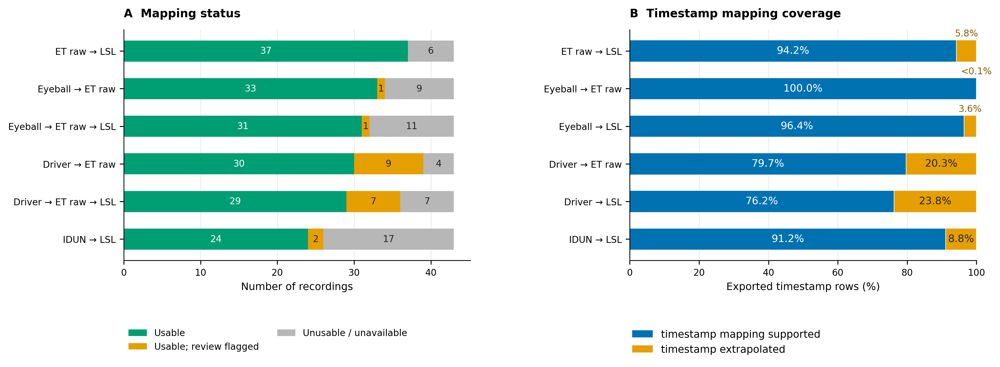

In [7]:
display(Image(filename=str(OUTPUT_DIR / '01_sync_quality_overview.png'), width=1300))

## Figure 3 · Pupil alignment by participant

Each participant has a separate before/after figure in PID/visit order. Set `WINDOW_SECONDS` at the top of the next cell (default: 20 seconds), then rerun that cell to update every participant figure. The window is centered at the full ET recording midpoint, calculated from the processed XDF's native `Recording timestamp` channel. Zero on the x-axis marks the midpoint. Both panels share their axis limits; the midpoint time is printed outside the figure.

ET and Eyeball data come only from the processed XDF's `ET`, `ET_labels`, `Eyeball`, and `Eyeball_labels` streams. ET pupil values use Eye Tracker rows with Valid pupil status; Eyeball pupil areas use high/medium confidence. Positive ET diameter and the square root of Eyeball area are standardized separately. The two Eyeball curves share the mean and standard deviation of their pooled excerpt samples.

Before correction, the Eyeball stream's native `eyeball_timestamp` is used; after correction, its stored `et_raw_timestamp` is used. Signals are displayed on a 20 Hz grid; interpolation gaps longer than 0.25 seconds remain missing. Missing stream pairs retain an availability panel.


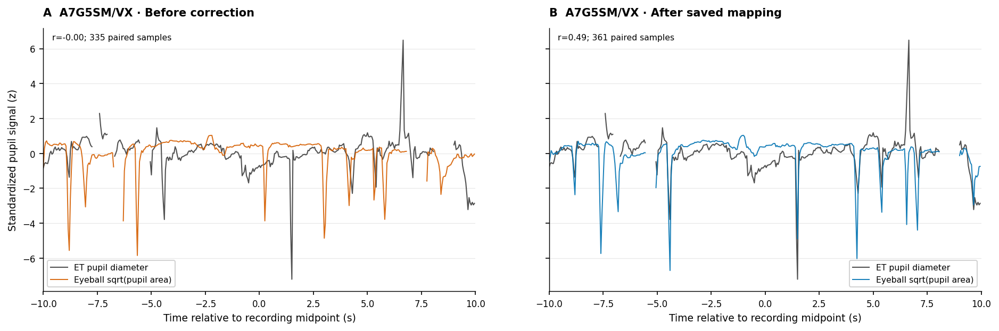

ET recording midpoint: 1358.6 s; window length: 20.0 s.


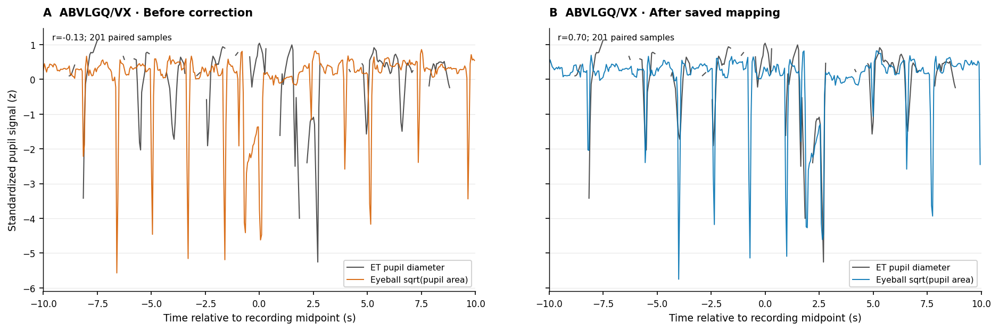

ET recording midpoint: 1366.1 s; window length: 20.0 s.


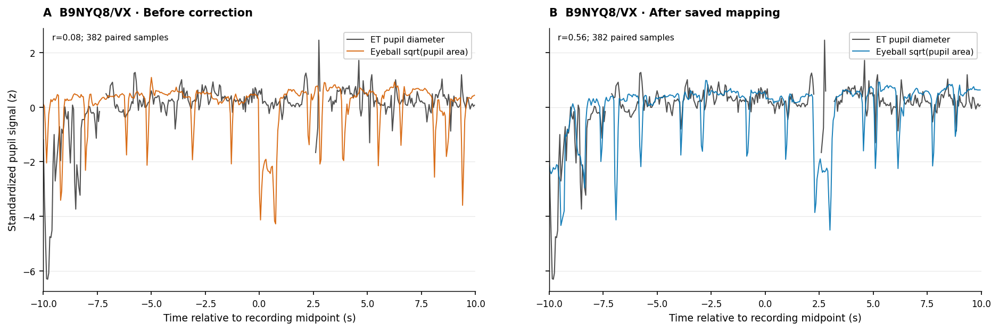

ET recording midpoint: 1365.3 s; window length: 20.0 s.


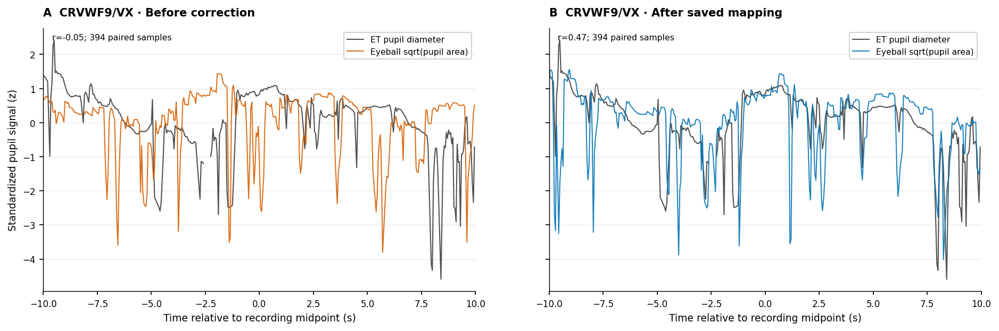

ET recording midpoint: 1366.1 s; window length: 20.0 s.


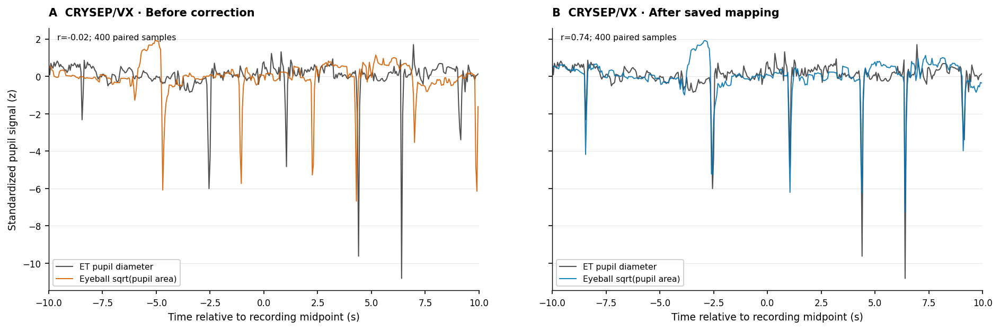

ET recording midpoint: 1371.0 s; window length: 20.0 s.


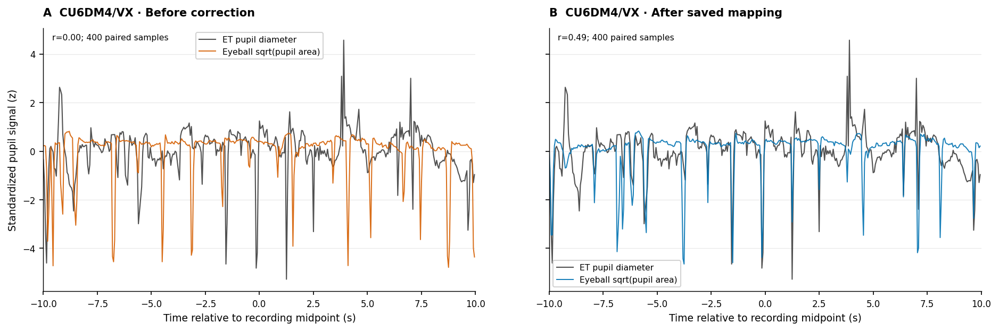

ET recording midpoint: 1443.0 s; window length: 20.0 s.


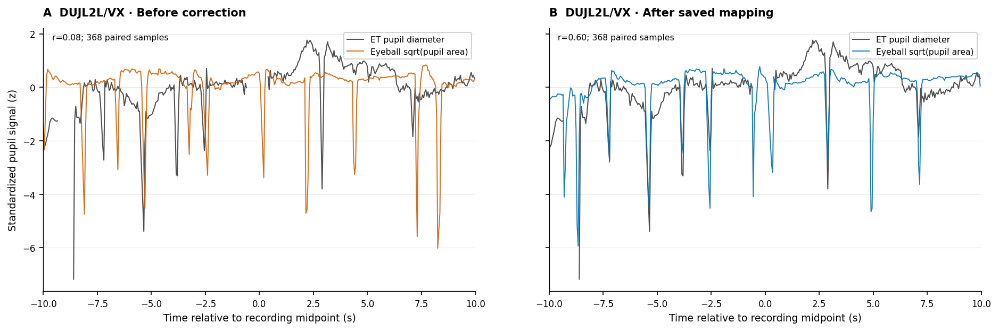

ET recording midpoint: 1388.0 s; window length: 20.0 s.


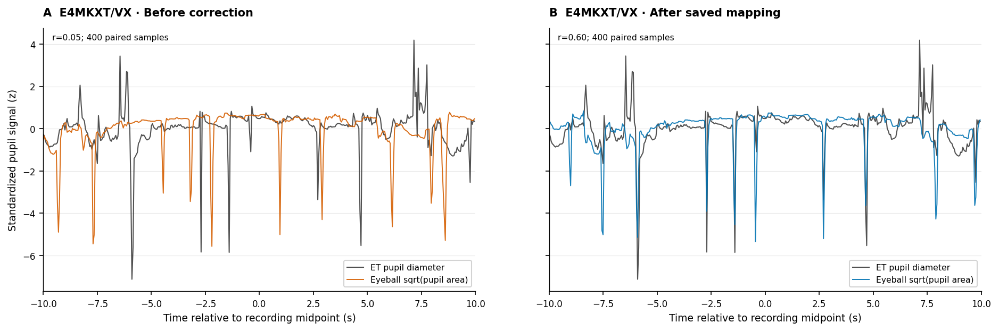

ET recording midpoint: 1383.3 s; window length: 20.0 s.


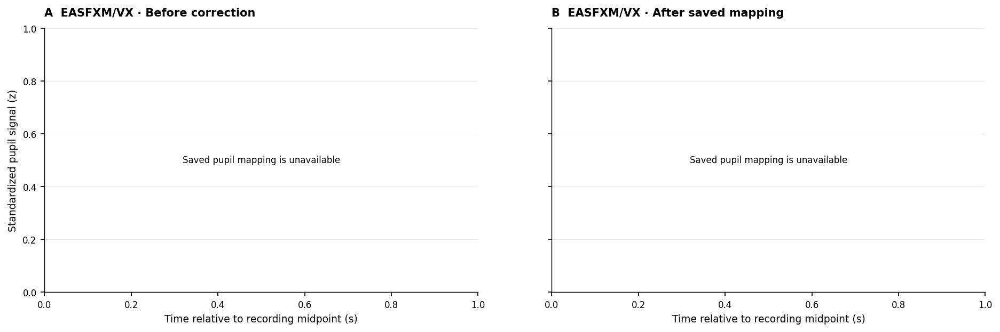

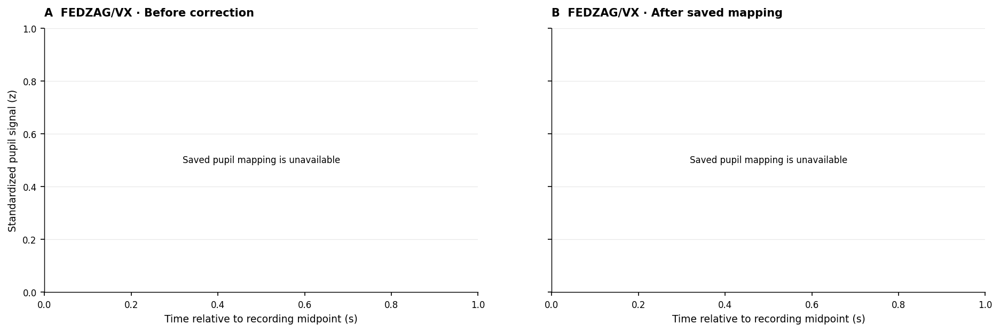

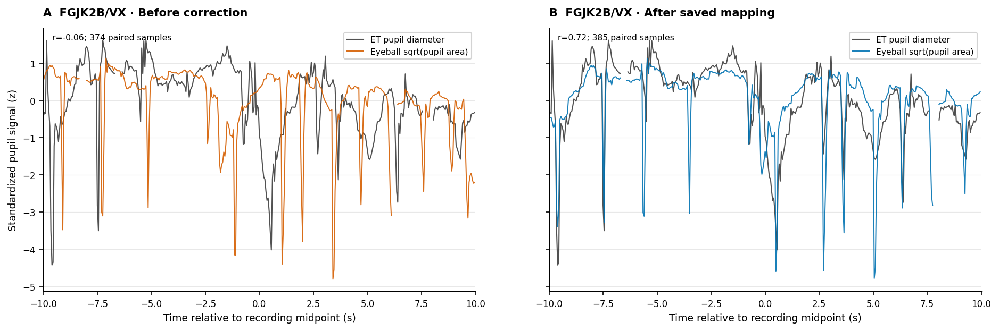

ET recording midpoint: 1354.6 s; window length: 20.0 s.


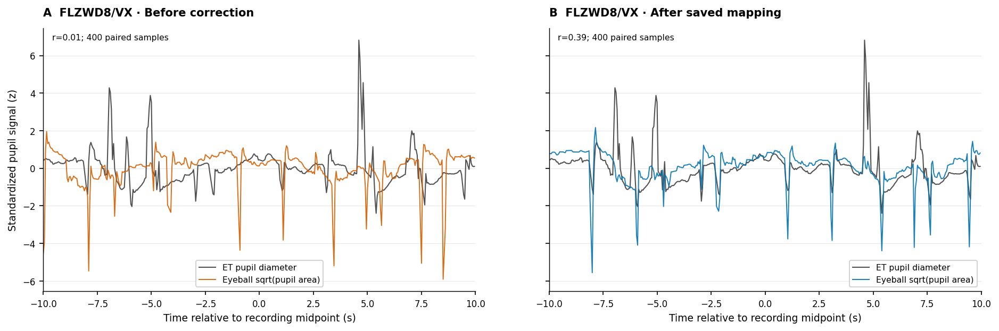

ET recording midpoint: 1361.1 s; window length: 20.0 s.


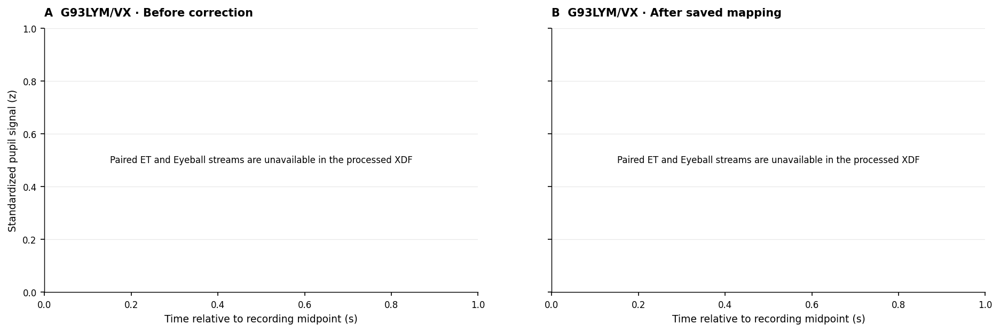

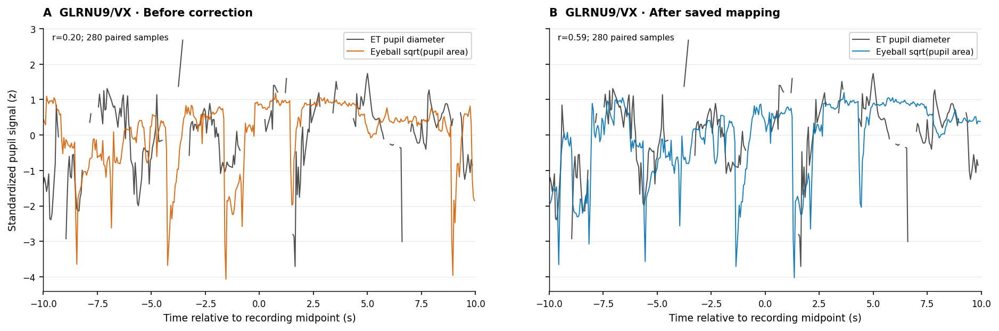

ET recording midpoint: 1134.0 s; window length: 20.0 s.


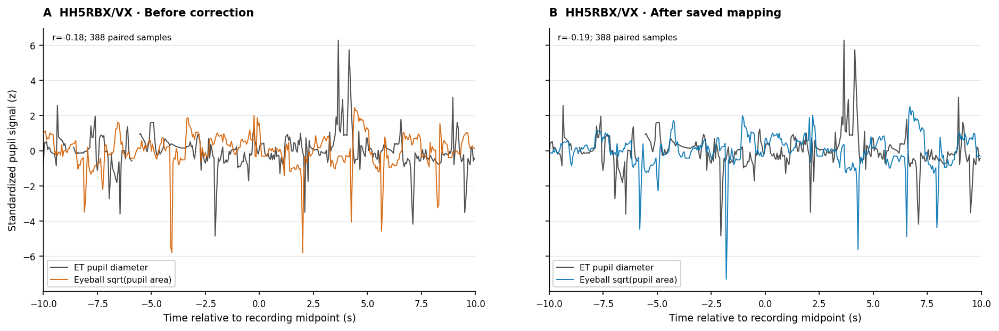

ET recording midpoint: 1310.8 s; window length: 20.0 s.


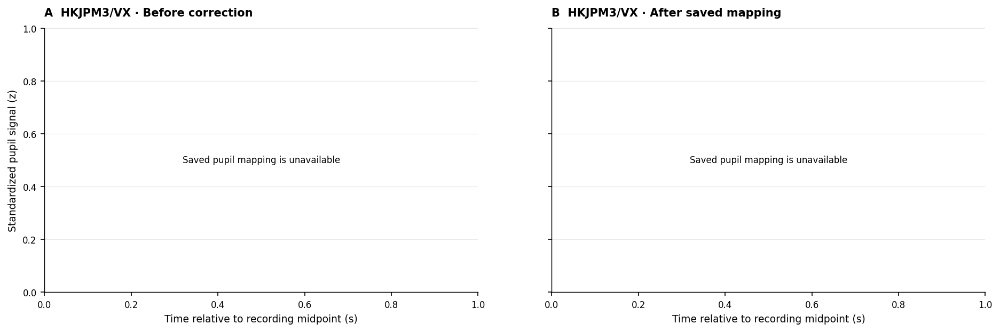

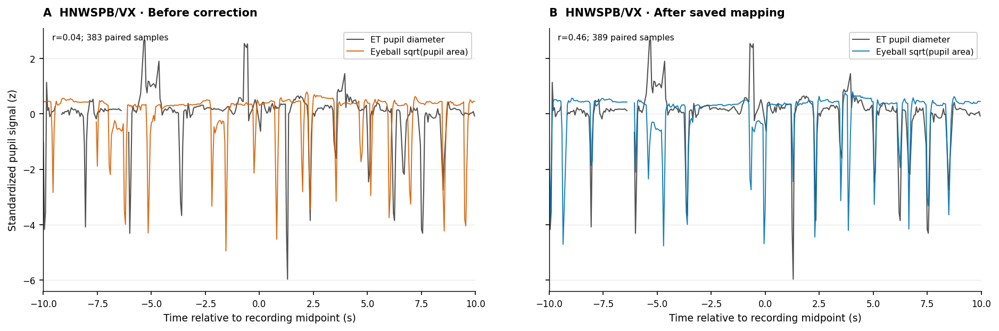

ET recording midpoint: 1297.9 s; window length: 20.0 s.


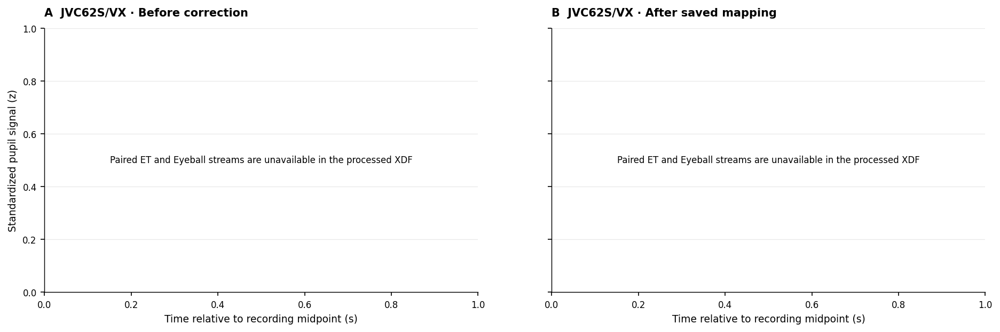

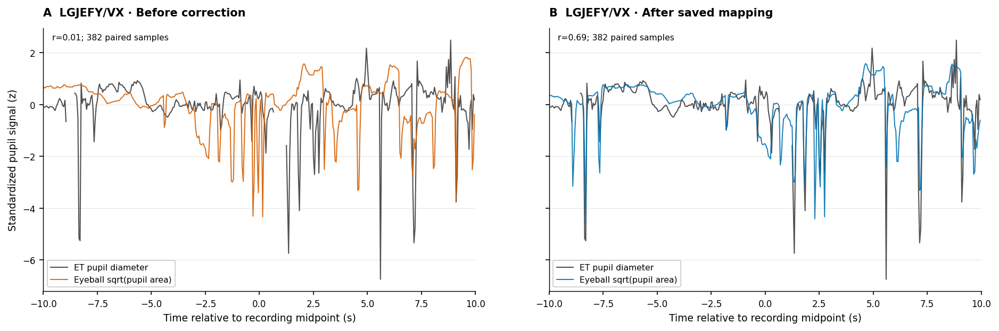

ET recording midpoint: 1357.9 s; window length: 20.0 s.


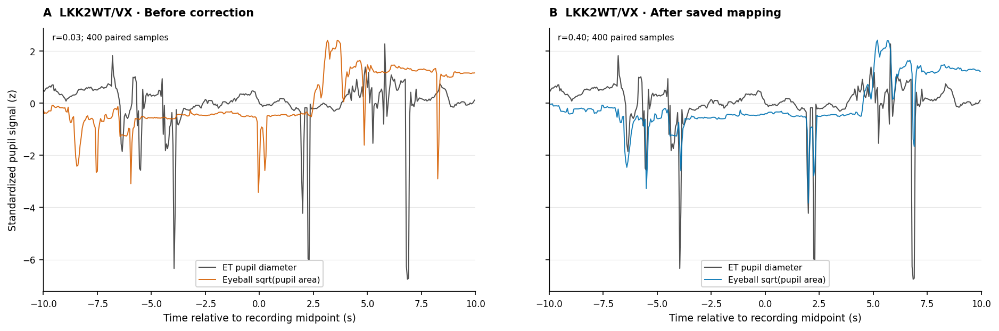

ET recording midpoint: 1377.1 s; window length: 20.0 s.


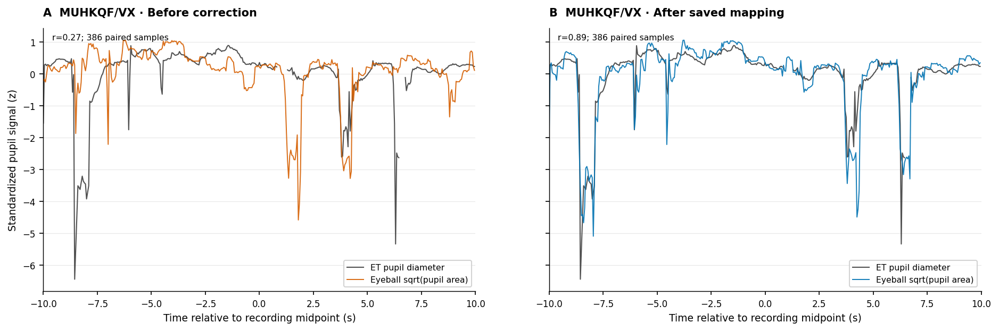

ET recording midpoint: 807.4 s; window length: 20.0 s.


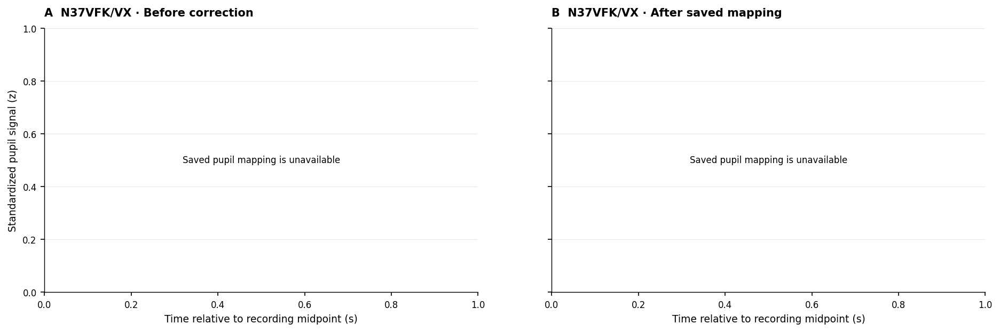

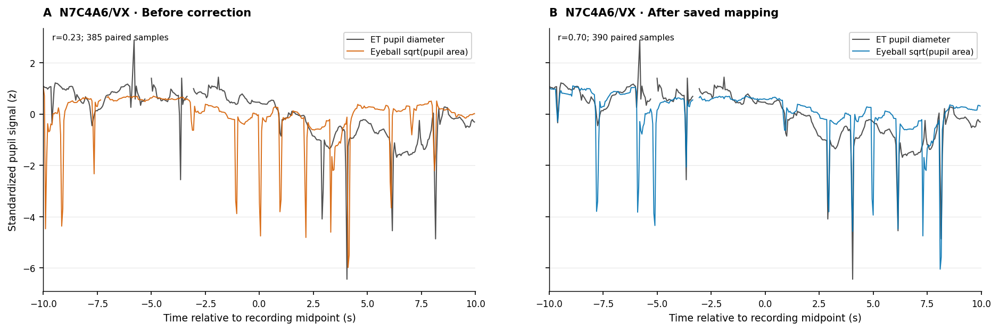

ET recording midpoint: 1367.6 s; window length: 20.0 s.


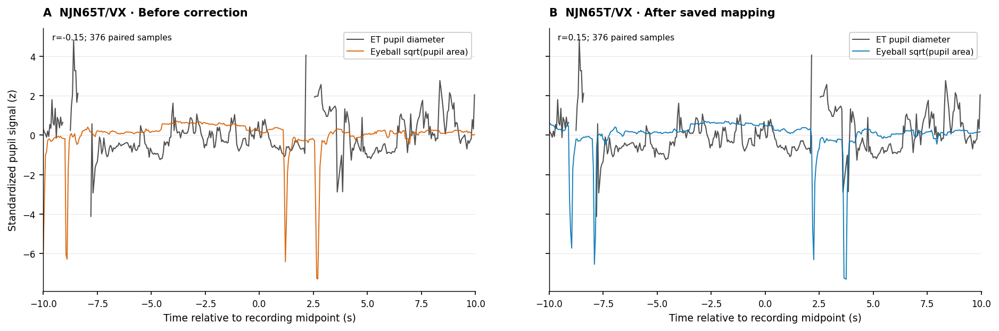

ET recording midpoint: 1376.9 s; window length: 20.0 s.


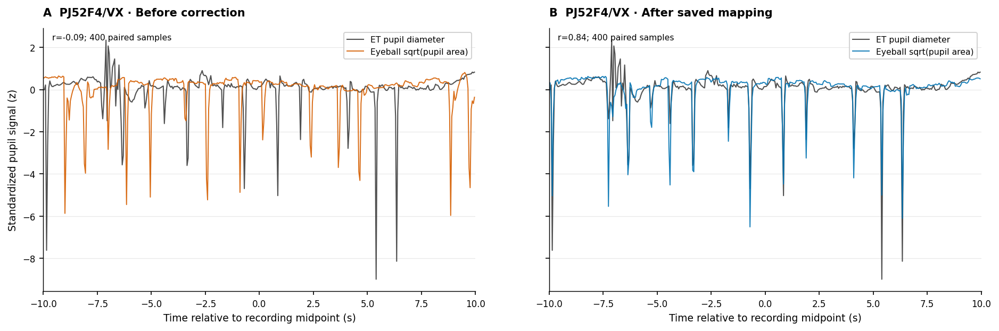

ET recording midpoint: 1367.9 s; window length: 20.0 s.


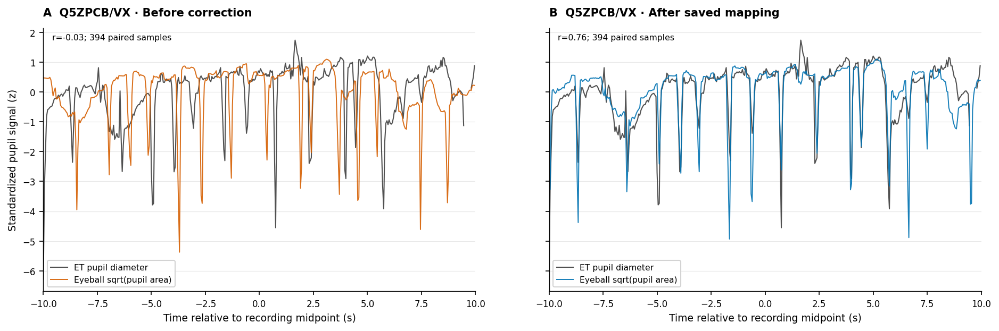

ET recording midpoint: 1370.9 s; window length: 20.0 s.


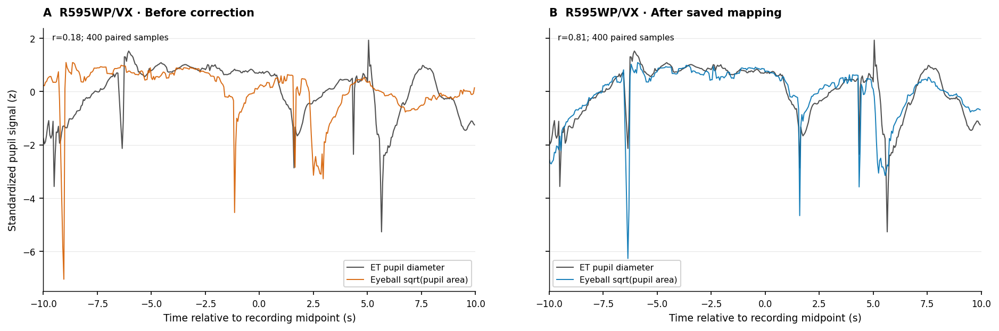

ET recording midpoint: 1367.6 s; window length: 20.0 s.


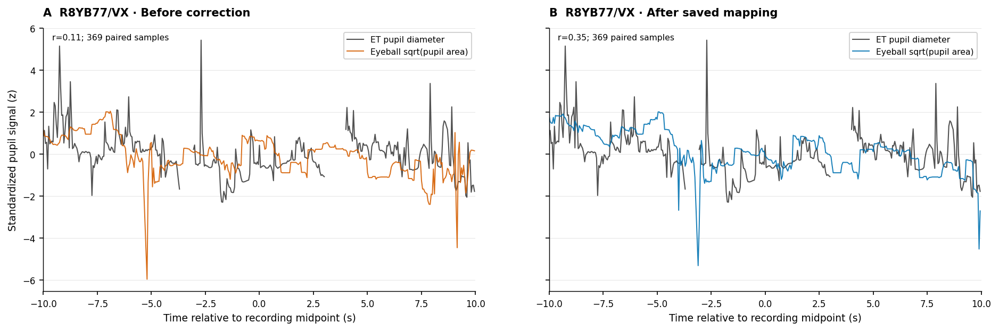

ET recording midpoint: 1386.5 s; window length: 20.0 s.


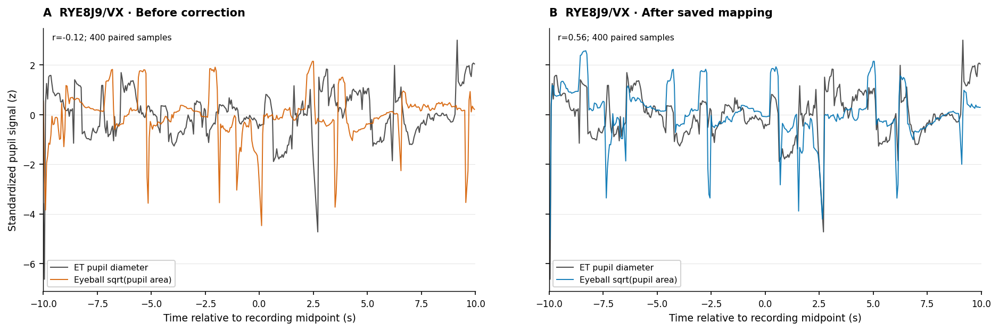

ET recording midpoint: 1397.3 s; window length: 20.0 s.


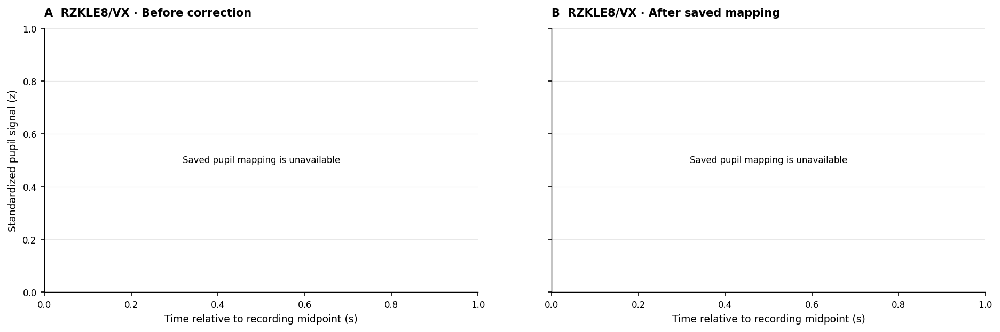

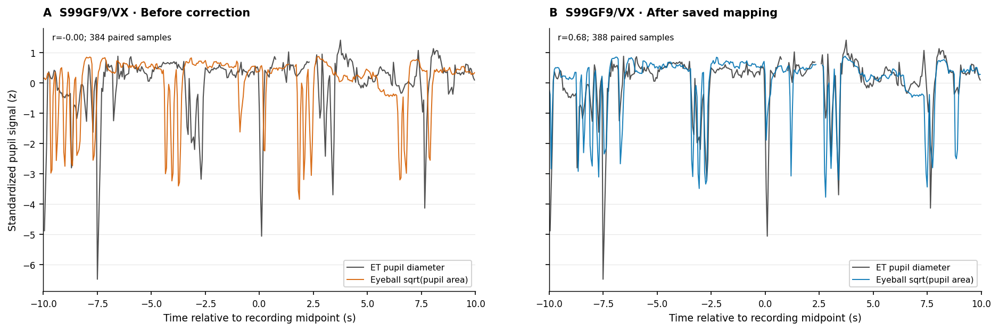

ET recording midpoint: 1290.1 s; window length: 20.0 s.


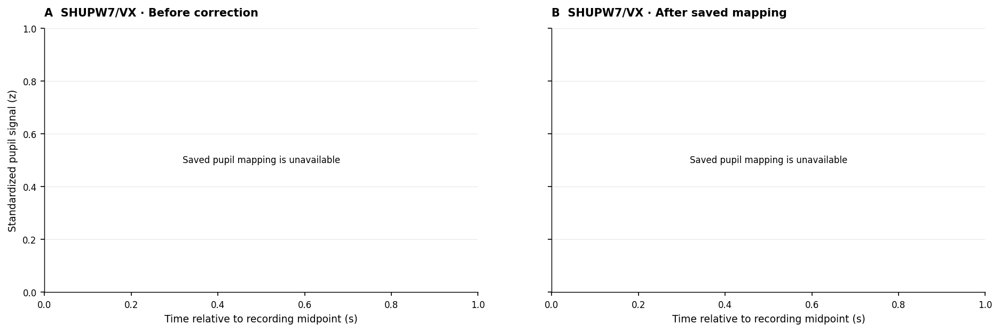

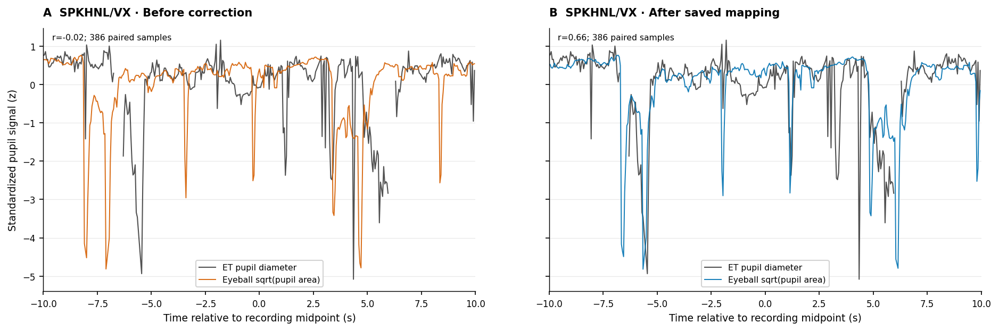

ET recording midpoint: 1367.0 s; window length: 20.0 s.


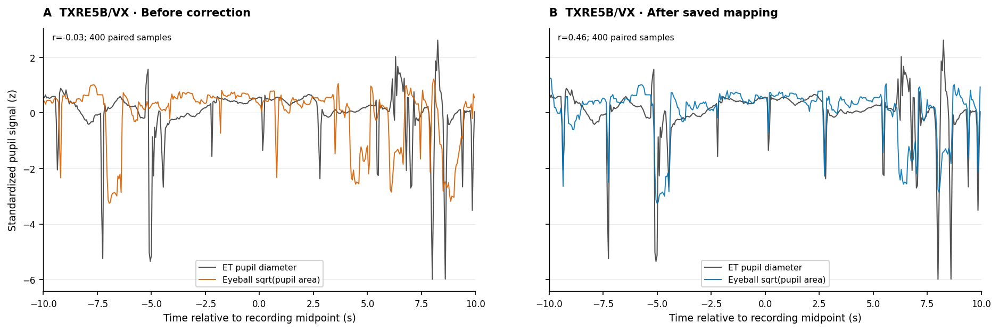

ET recording midpoint: 1346.3 s; window length: 20.0 s.


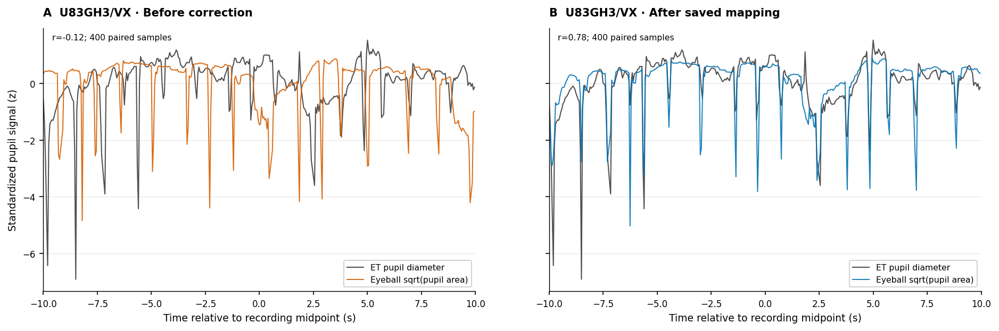

ET recording midpoint: 1384.8 s; window length: 20.0 s.


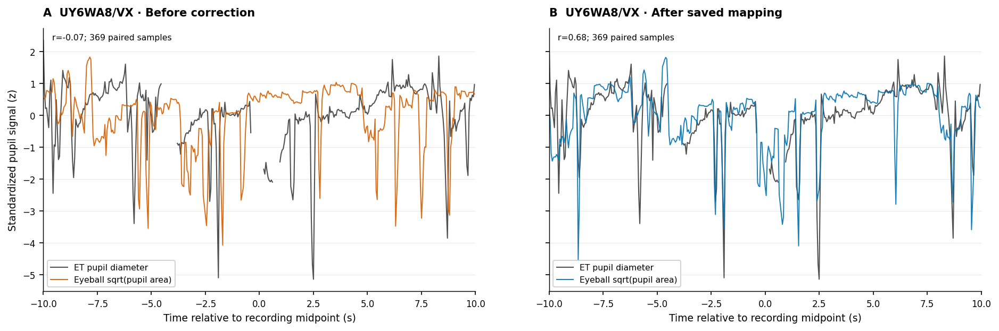

ET recording midpoint: 1375.6 s; window length: 20.0 s.


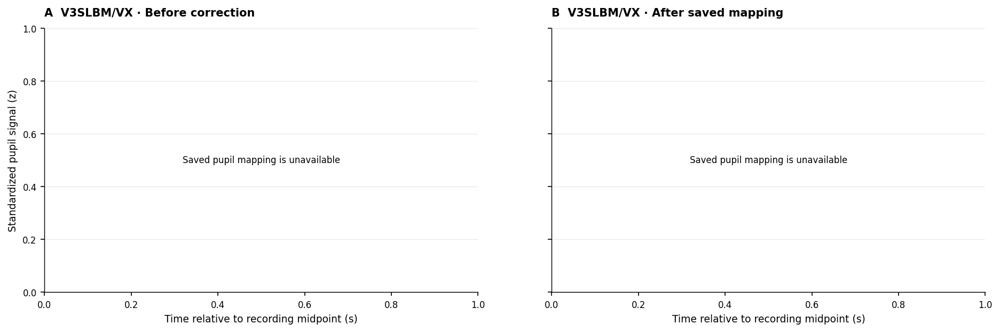

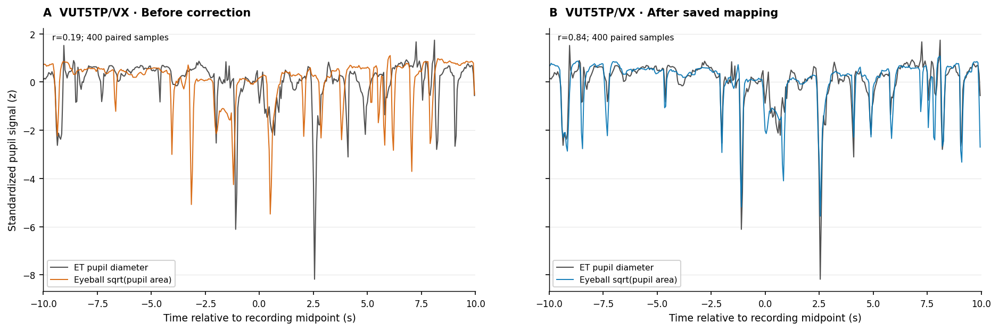

ET recording midpoint: 1372.2 s; window length: 20.0 s.


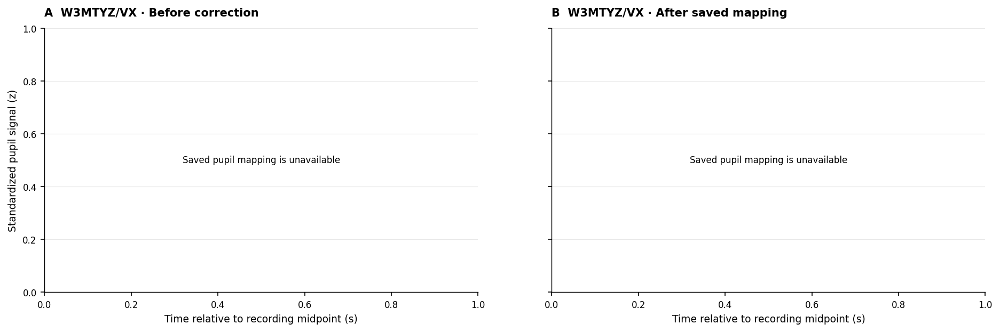

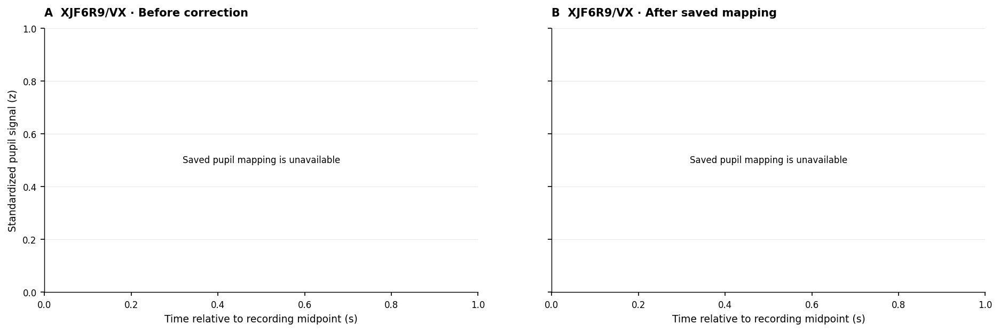

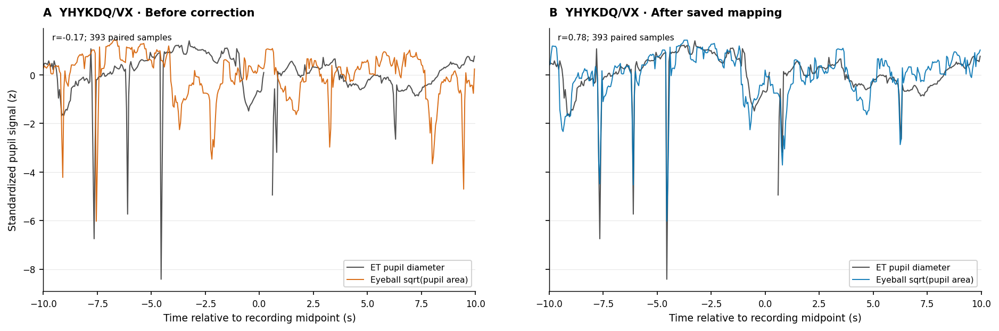

ET recording midpoint: 1369.9 s; window length: 20.0 s.


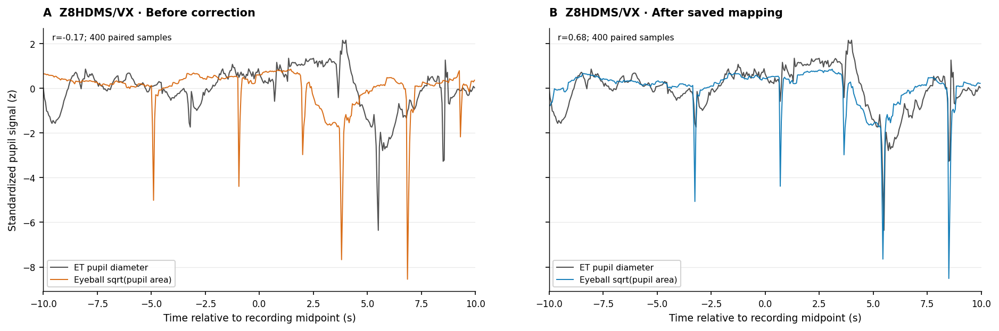

ET recording midpoint: 1389.3 s; window length: 20.0 s.


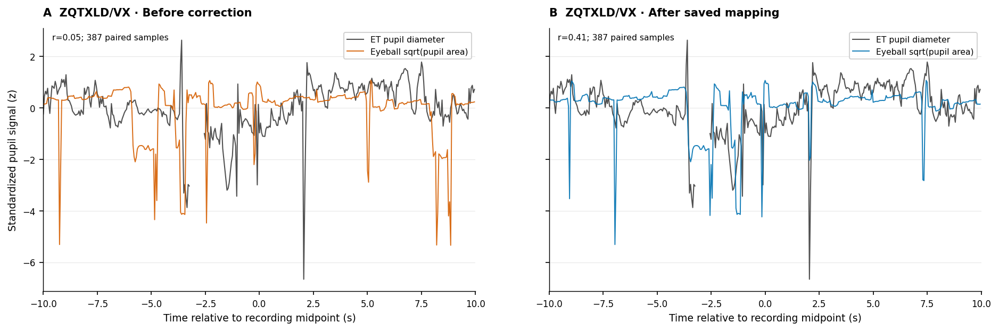

ET recording midpoint: 1434.8 s; window length: 20.0 s.
Saved 43 participant figures using a 20-second window.


In [8]:
WINDOW_SECONDS = 20  # Change the window length here, in seconds, then rerun this cell.

if not np.isfinite(WINDOW_SECONDS) or WINDOW_SECONDS <= 0:
    raise ValueError('WINDOW_SECONDS must be a positive number.')

PUPIL_EXCERPTS = []
PUPIL_FIGURE_PATHS = []
if INCLUDE_PUPIL_EXAMPLES:
    pupil_figure_dir = OUTPUT_DIR / '03_pupil_alignment'
    pupil_figure_dir.mkdir(parents=True, exist_ok=True)
    for _, mapping in QC_TABLES['et_eyeball_alignment_csv'].sort_values(['pid', 'visit']).iterrows():
        excerpt = load_pupil_example(CONFIG, mapping, duration_s=WINDOW_SECONDS)
        PUPIL_EXCERPTS.append(excerpt)
        name = f"{excerpt['pid']}_{excerpt['visit']}"
        figure = plot_pupil_examples([excerpt])
        for extension in ('png', 'svg'):
            figure.savefig(pupil_figure_dir / f'{name}.{extension}', dpi=150, bbox_inches='tight')
        plt.close(figure)
        path = pupil_figure_dir / f'{name}.png'
        PUPIL_FIGURE_PATHS.append(path)
        display(Image(filename=str(path), width=1300))
        if excerpt['available']:
            print(f"ET recording midpoint: {(excerpt['start_et_s'] + excerpt['end_et_s']) / 2:.1f} s; window length: {excerpt['end_et_s'] - excerpt['start_et_s']:.1f} s.")

(OUTPUT_DIR / 'pupil_examples.json').write_text(
    json.dumps(json_values(PUPIL_EXCERPTS), ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
print(f'Saved {len(PUPIL_FIGURE_PATHS)} participant figures using a {WINDOW_SECONDS:g}-second window.')


## Figure 4 · IDUN and cap EEG alignment by participant

Each participant has a separate before/after figure, in PID/visit order, including the same availability panels as Figure 3. Set `EEG_WINDOW_SECONDS` at the top of the next cell (default: 20 seconds), then rerun that cell to regenerate all participant figures. Each window is centered at the cap EEG recording midpoint; zero on the x-axis marks that midpoint. Both panels share their axis limits. The midpoint and window length are printed outside the figure.

Cap EEG is read from the processed XDF's `EEGfm` stream. IDUN raw EEG is used to construct the native before/after comparison. Curves show the EEG activity envelopes used for synchronization, using each recording's saved cap channel or channel difference. The existing Step 05 preprocessing is applied over the full original overlap: resampling to 50 Hz, subtracting a 2-second moving mean, clipping at 10 scaled MADs, calculating a 0.5-second RMS envelope, and downsampling to 10 Hz. Cap EEG and IDUN are standardized separately for display; both IDUN panels share the mean and standard deviation of their pooled excerpt samples.

Before content correction, IDUN times use the saved arrival-time search prior. After correction, they use the saved affine IDUN-to-LSL mapping. The same IDUN envelope is used in both panels, with only its time coordinates changed. Signal features are cached in memory so changing the window length does not reload the XDF files. No timing fit is rerun.


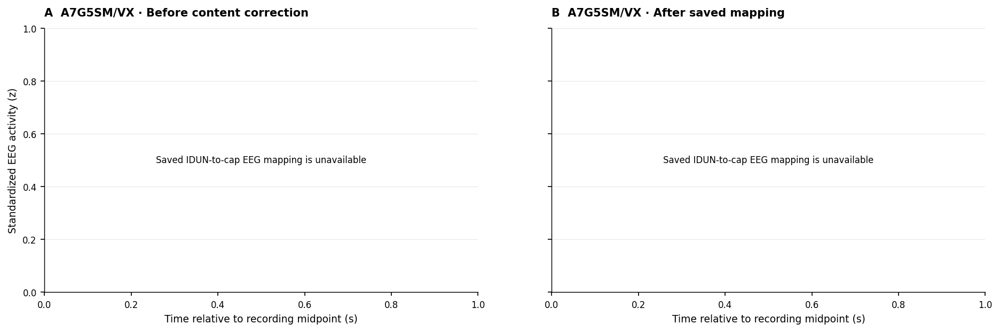

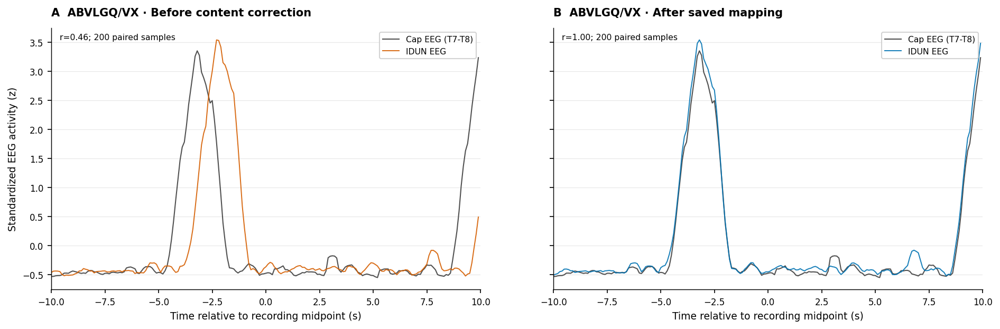

Cap EEG recording midpoint: 26931.6 s (LSL); window length: 20.0 s.


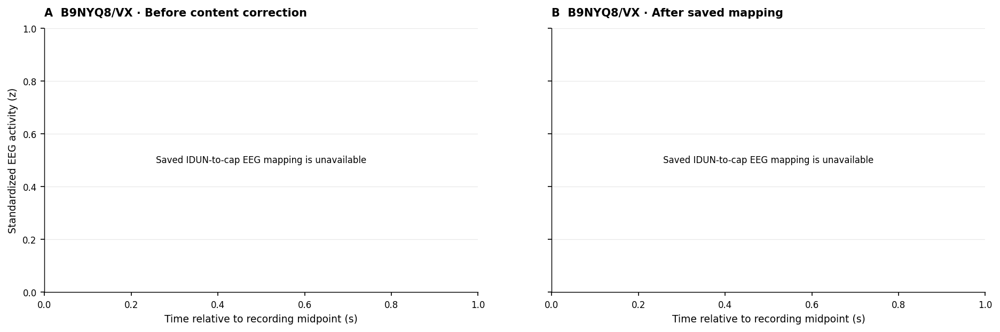

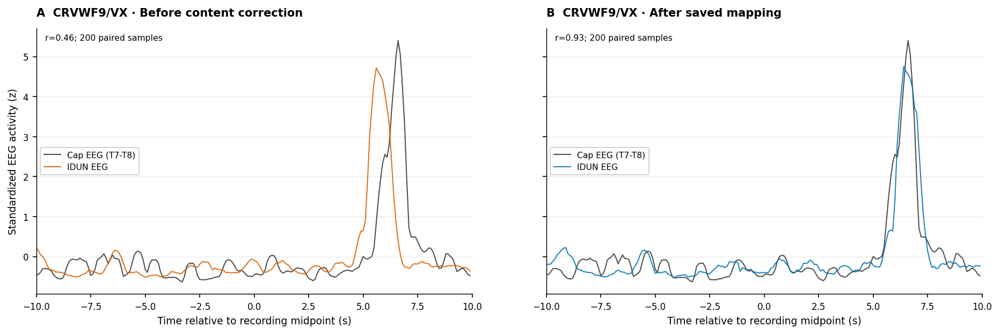

Cap EEG recording midpoint: 20201.6 s (LSL); window length: 20.0 s.


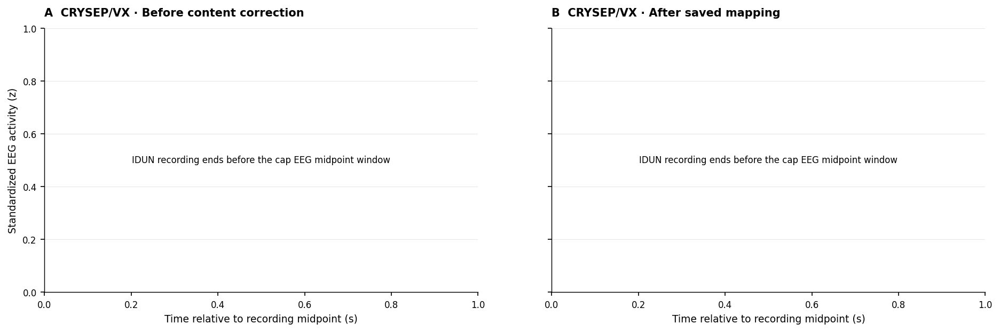

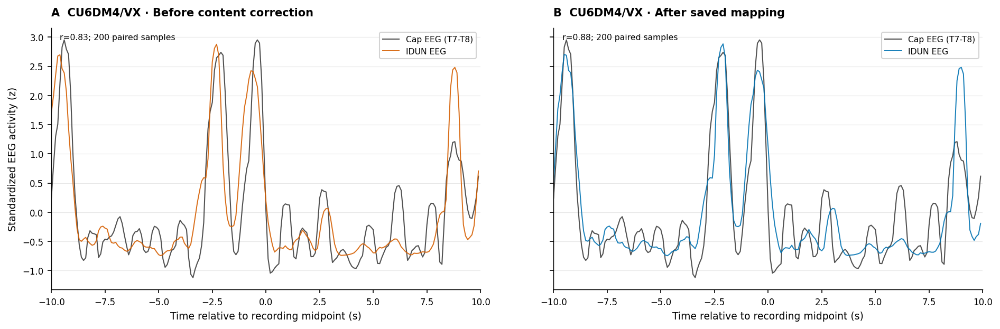

Cap EEG recording midpoint: 610069.1 s (LSL); window length: 20.0 s.


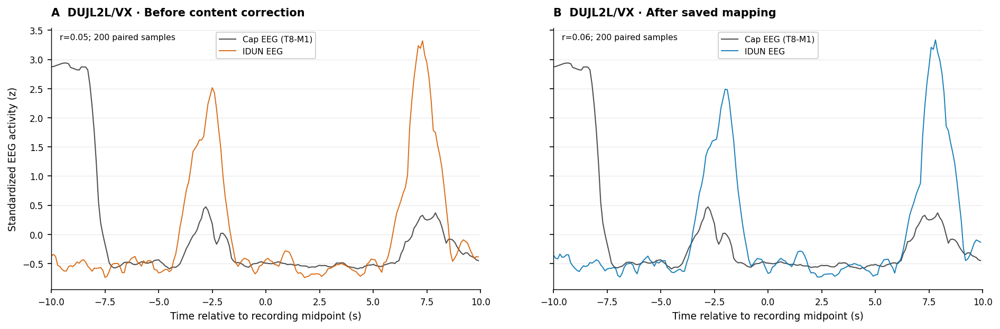

Cap EEG recording midpoint: 625979.2 s (LSL); window length: 20.0 s.


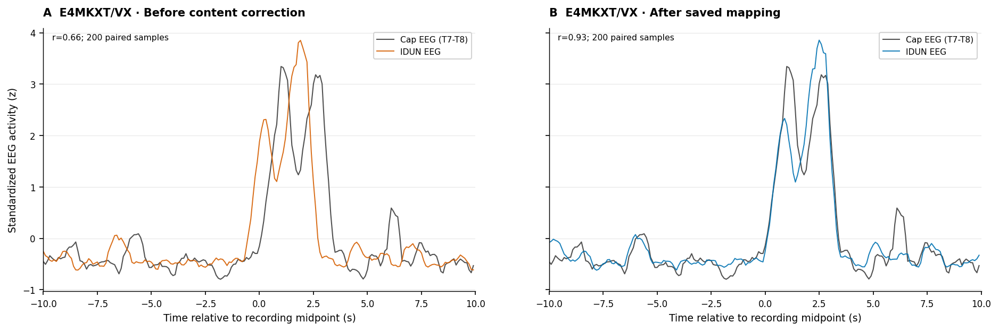

Cap EEG recording midpoint: 90653.8 s (LSL); window length: 20.0 s.


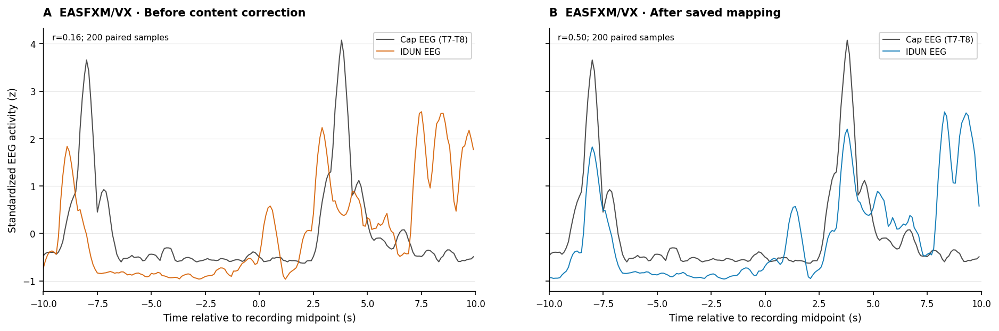

Cap EEG recording midpoint: 61056.9 s (LSL); window length: 20.0 s.


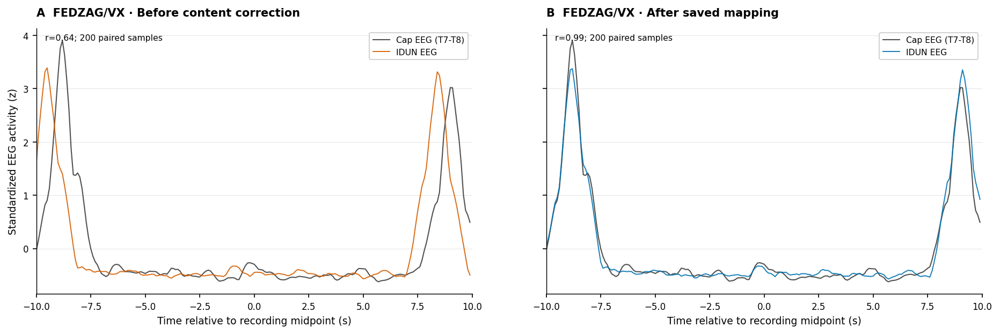

Cap EEG recording midpoint: 9597.8 s (LSL); window length: 20.0 s.


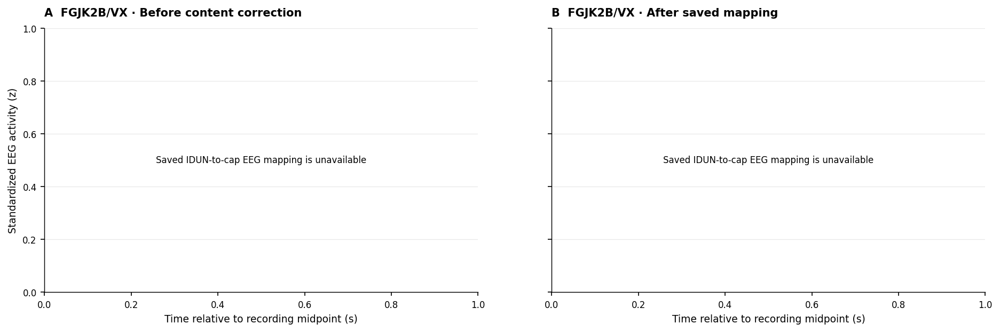

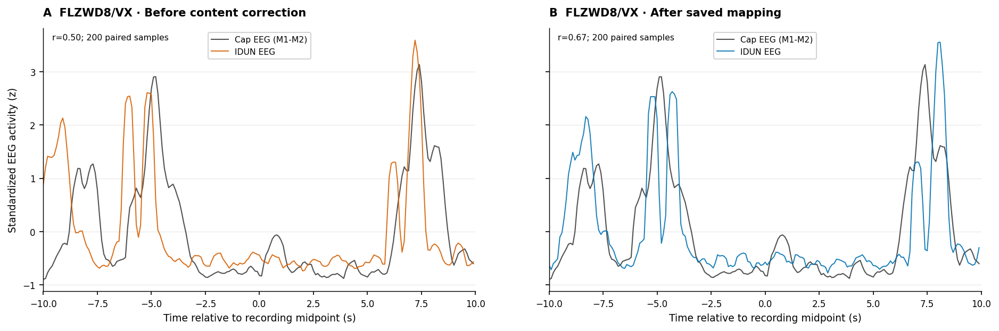

Cap EEG recording midpoint: 104096.7 s (LSL); window length: 20.0 s.


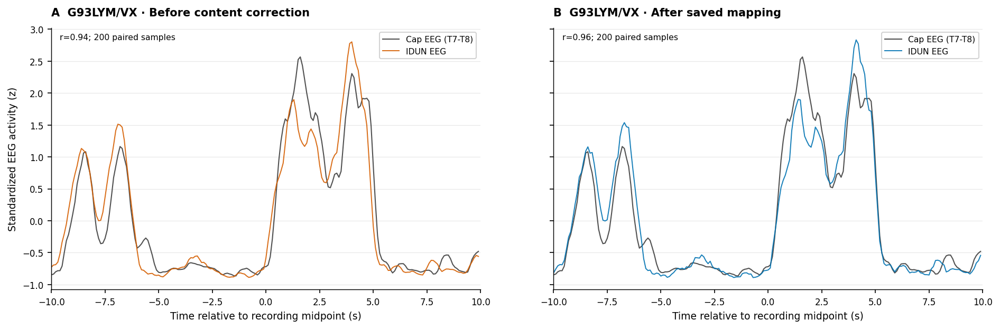

Cap EEG recording midpoint: 103094.4 s (LSL); window length: 20.0 s.


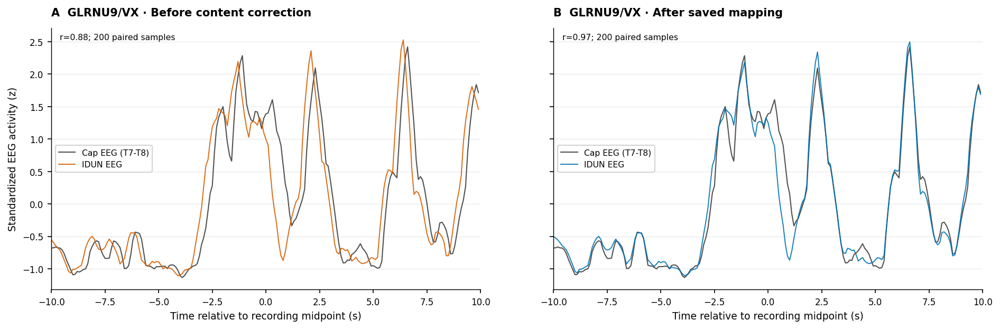

Cap EEG recording midpoint: 5352.7 s (LSL); window length: 20.0 s.


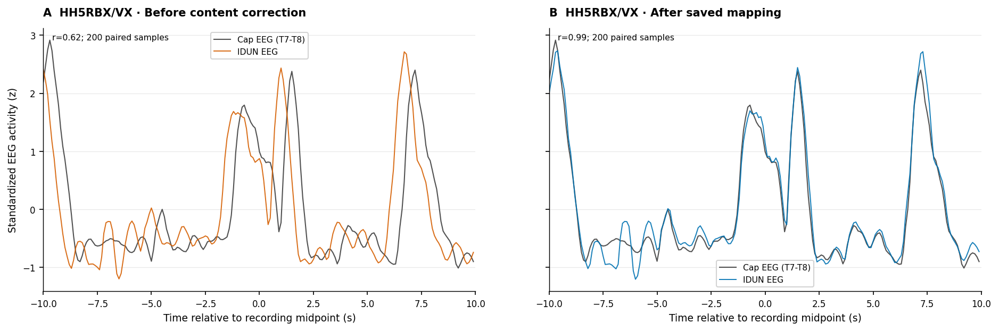

Cap EEG recording midpoint: 15955.6 s (LSL); window length: 20.0 s.


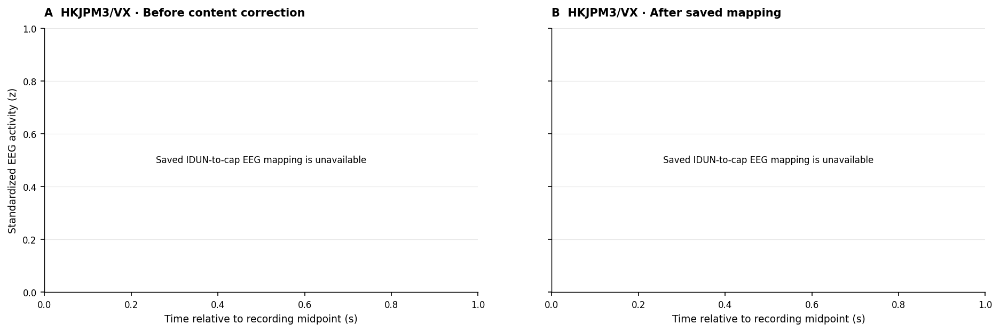

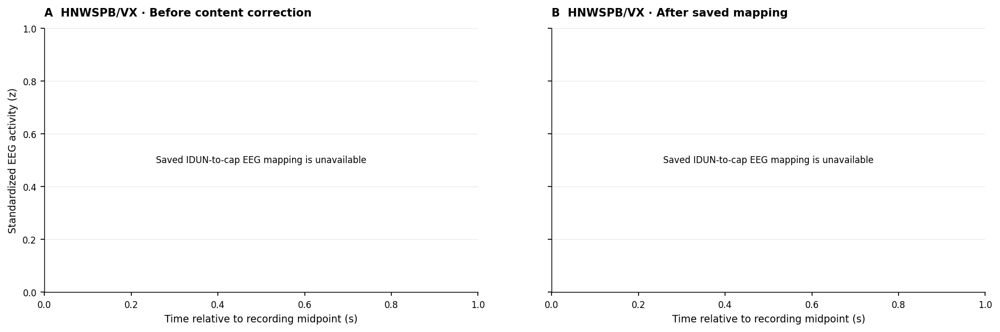

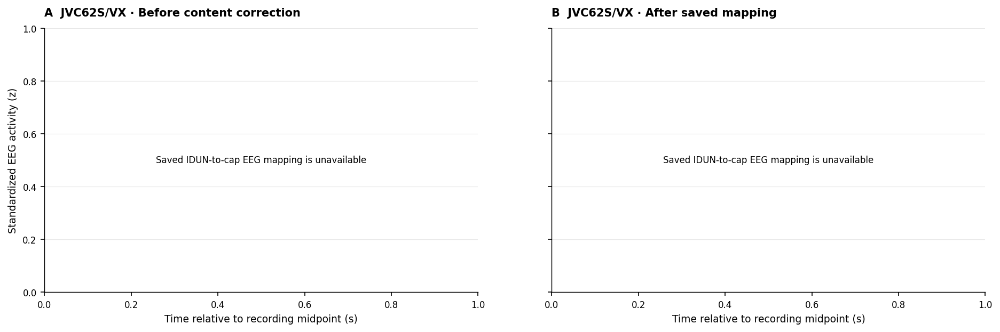

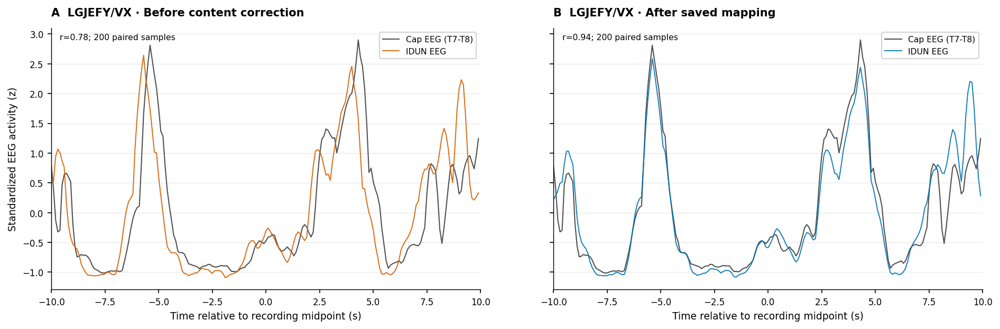

Cap EEG recording midpoint: 614822.0 s (LSL); window length: 20.0 s.


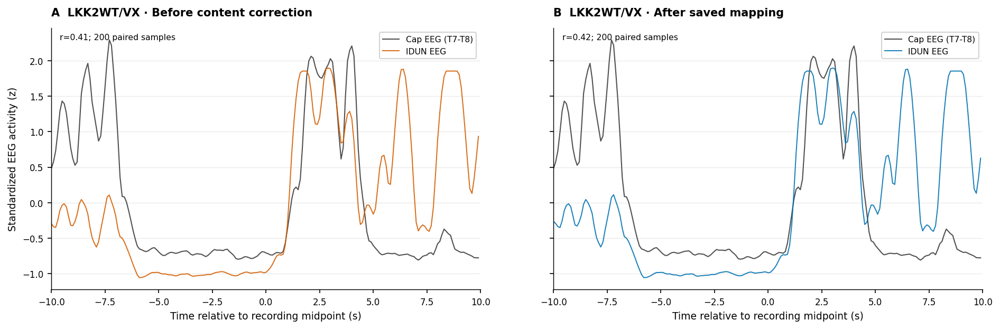

Cap EEG recording midpoint: 16144.2 s (LSL); window length: 20.0 s.


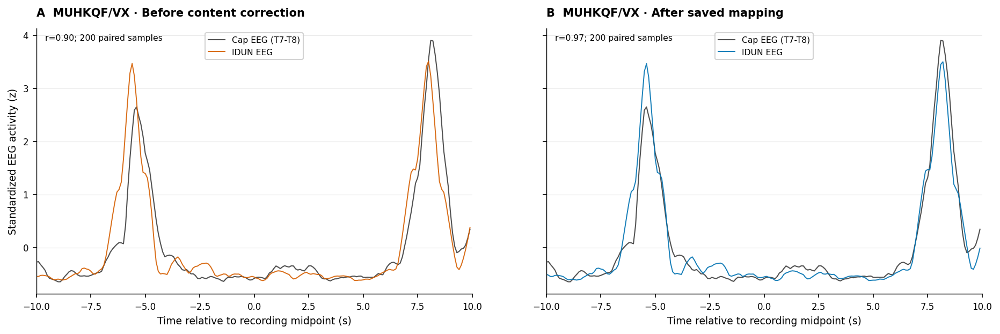

Cap EEG recording midpoint: 99270.0 s (LSL); window length: 20.0 s.


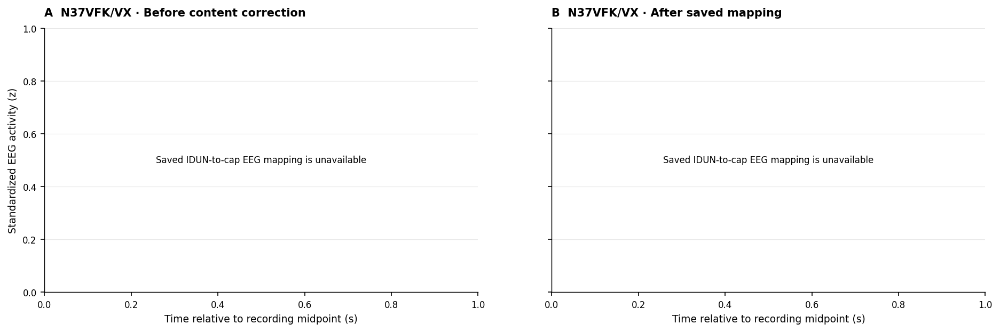

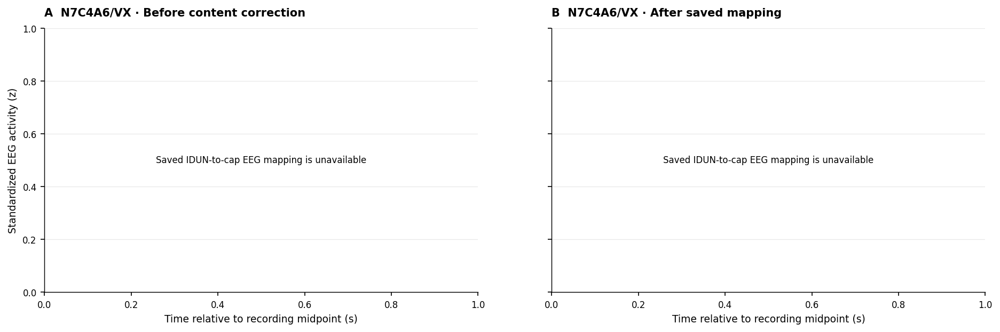

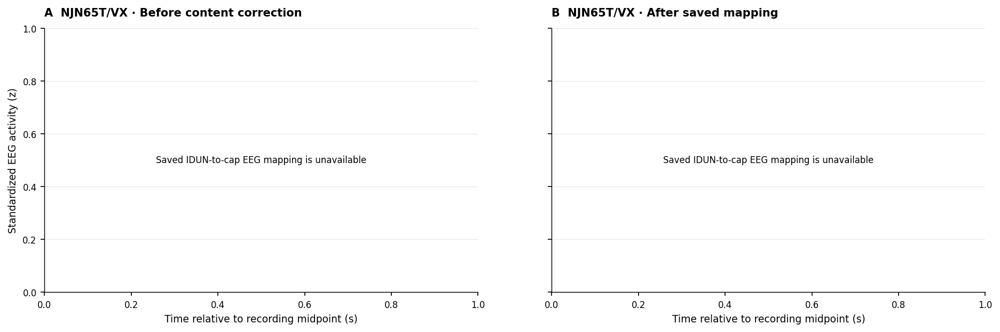

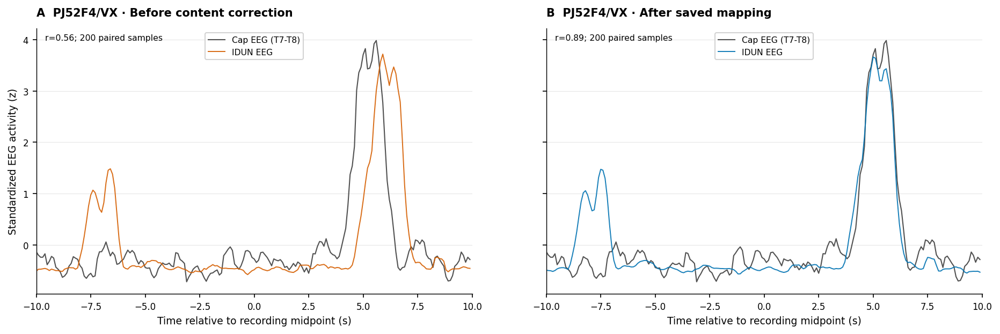

Cap EEG recording midpoint: 20779.3 s (LSL); window length: 20.0 s.


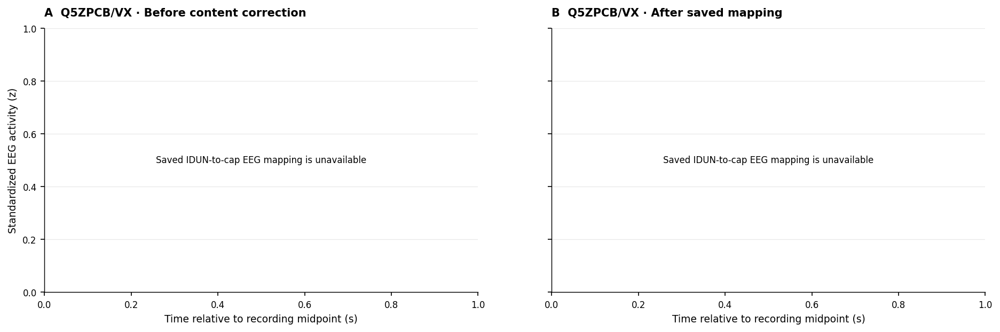

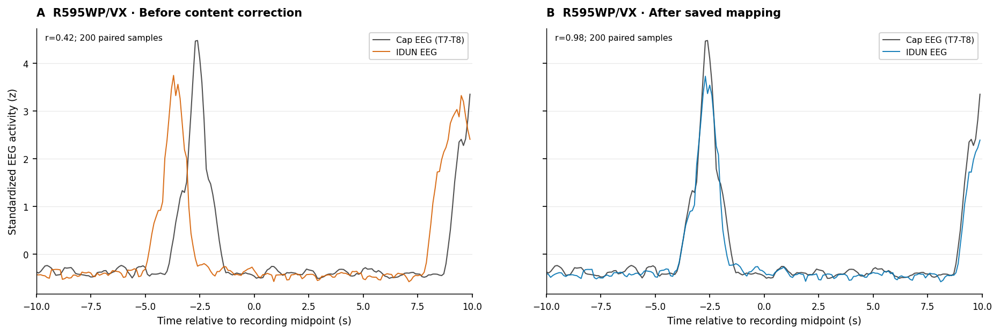

Cap EEG recording midpoint: 113158.3 s (LSL); window length: 20.0 s.


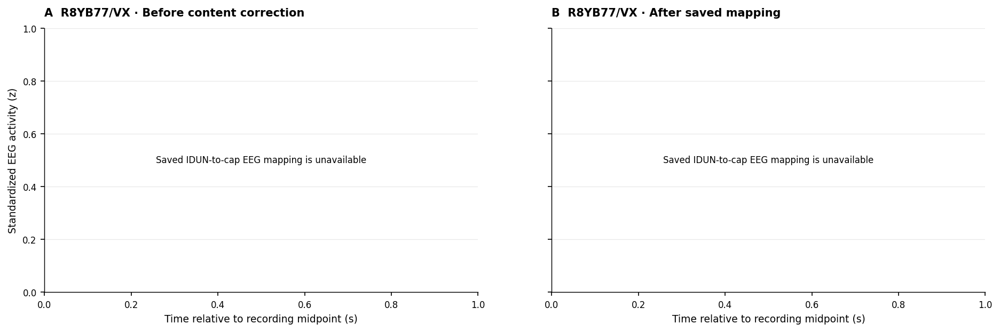

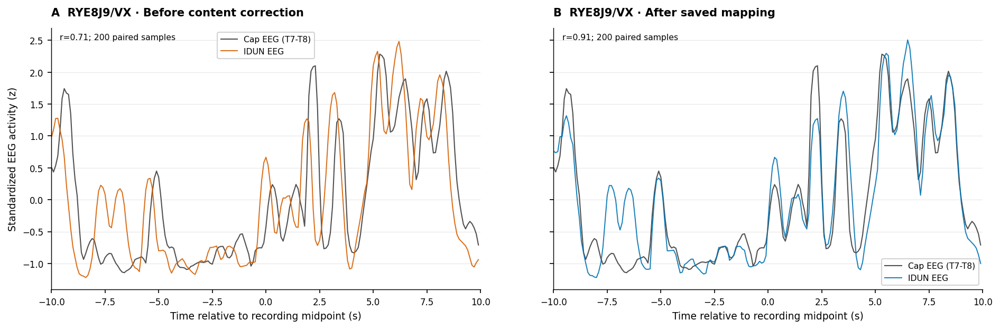

Cap EEG recording midpoint: 14868.0 s (LSL); window length: 20.0 s.


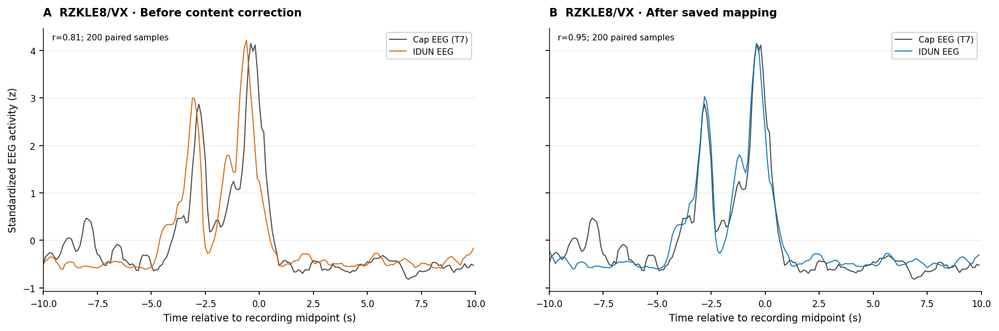

Cap EEG recording midpoint: 620294.2 s (LSL); window length: 20.0 s.


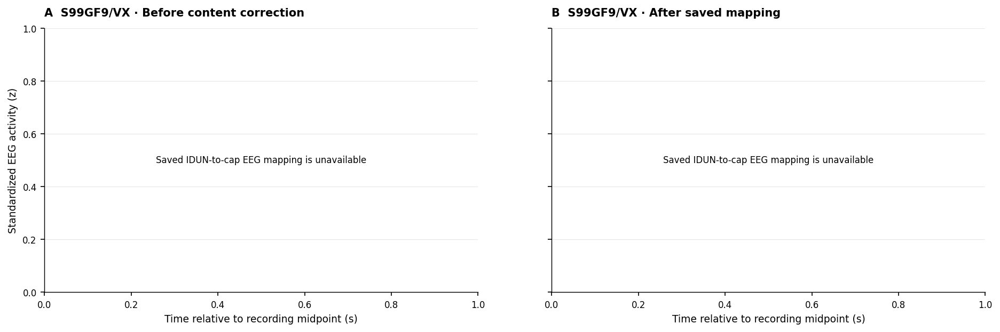

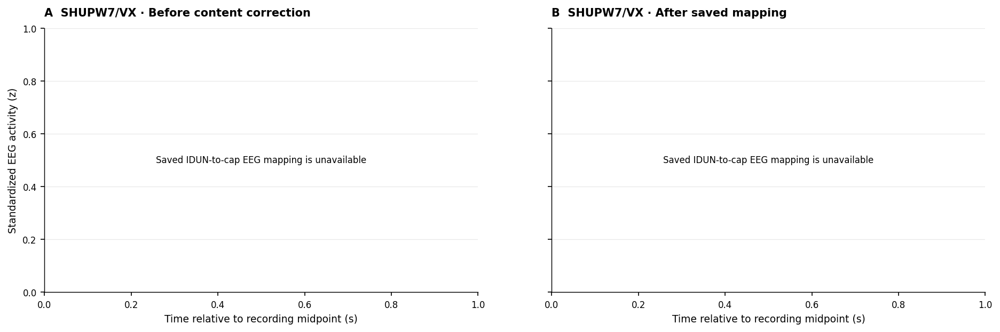

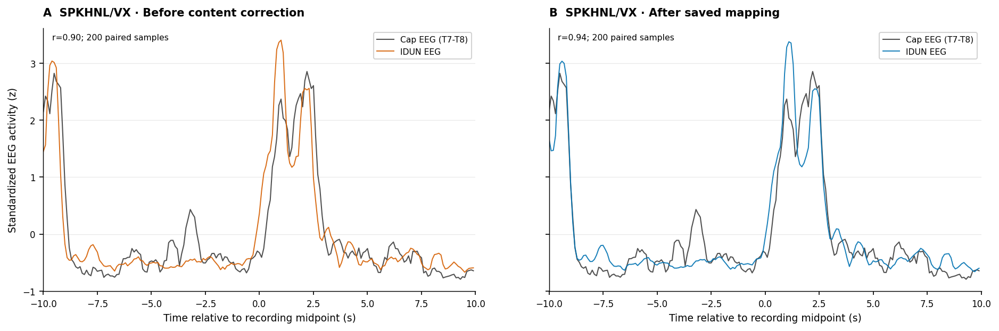

Cap EEG recording midpoint: 4029.6 s (LSL); window length: 20.0 s.


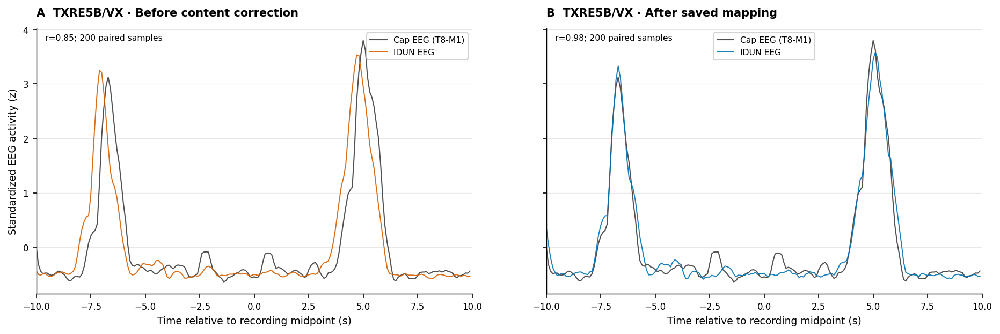

Cap EEG recording midpoint: 8918.0 s (LSL); window length: 20.0 s.


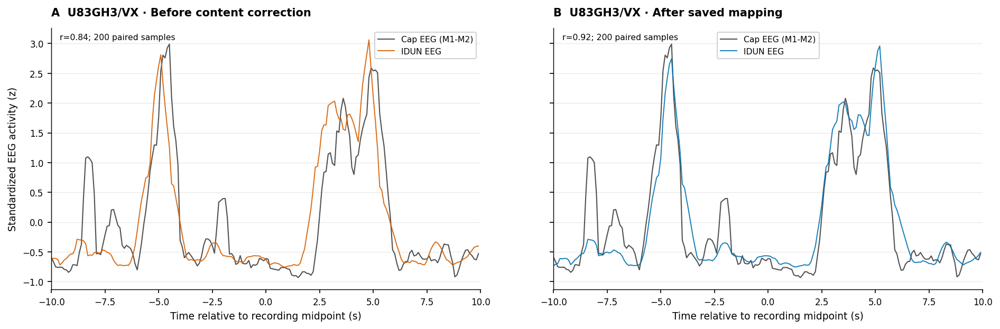

Cap EEG recording midpoint: 8304.4 s (LSL); window length: 20.0 s.


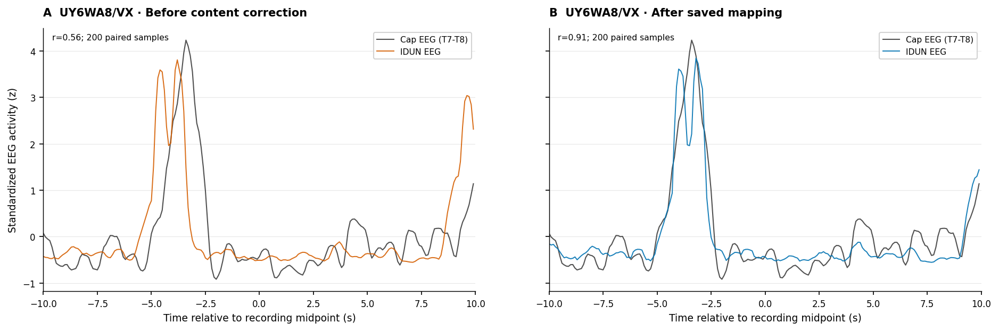

Cap EEG recording midpoint: 8800.1 s (LSL); window length: 20.0 s.


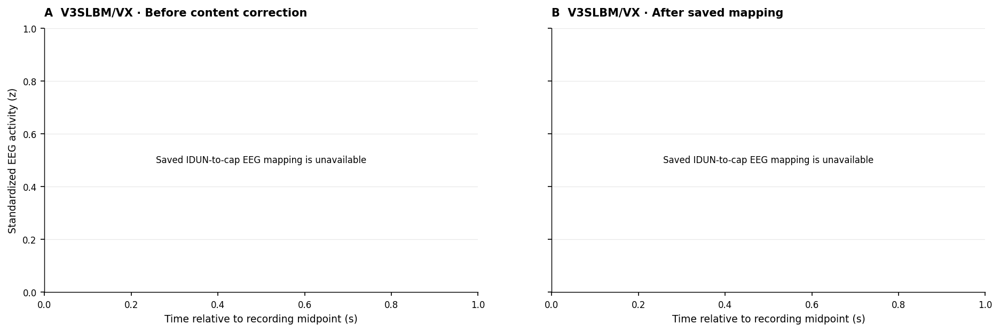

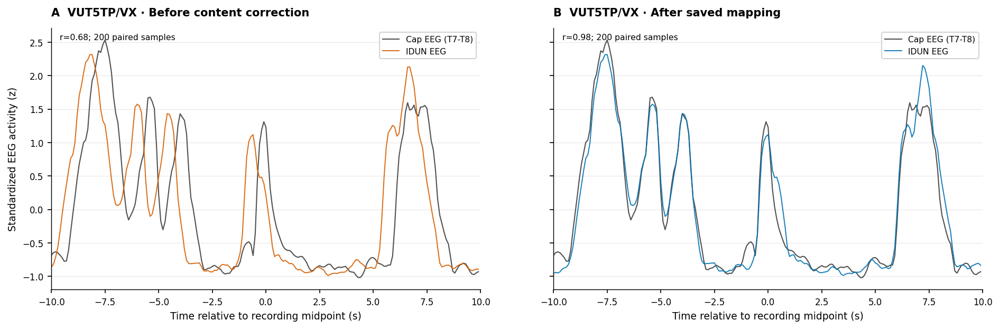

Cap EEG recording midpoint: 91696.9 s (LSL); window length: 20.0 s.


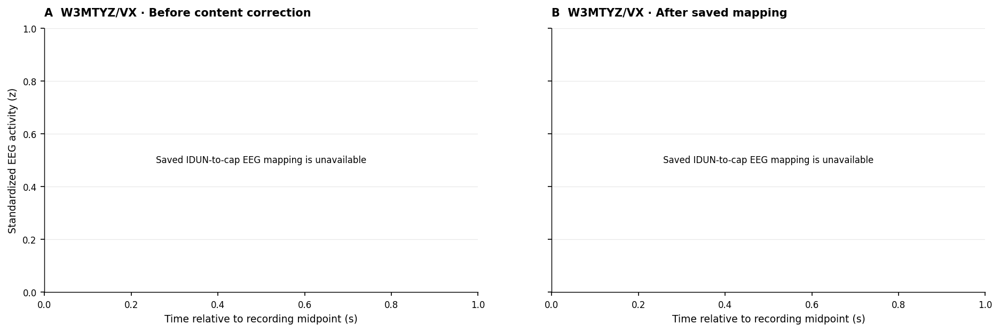

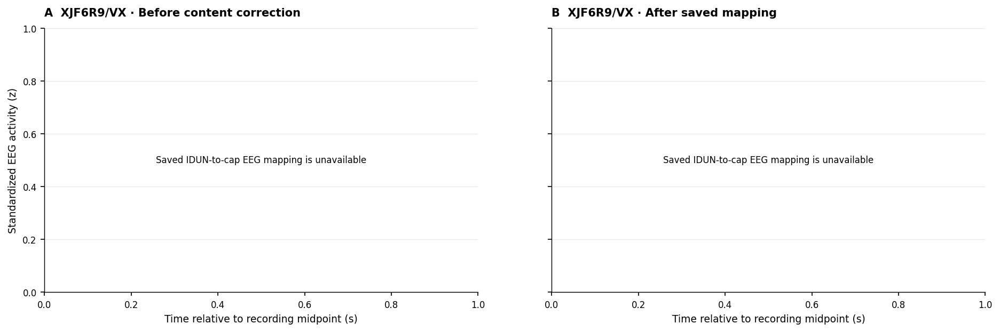

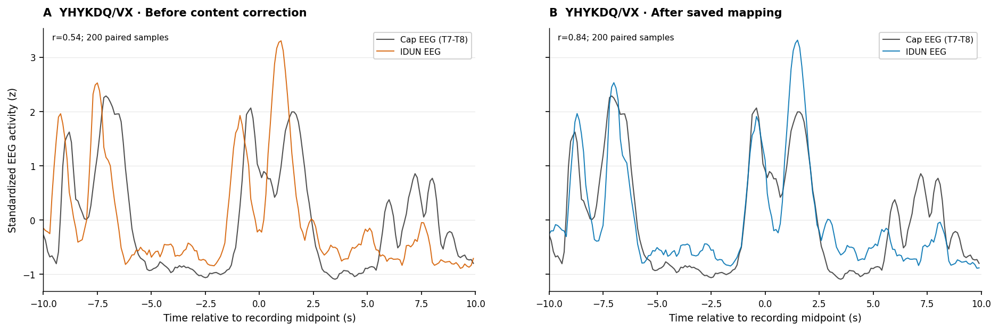

Cap EEG recording midpoint: 29272.1 s (LSL); window length: 20.0 s.


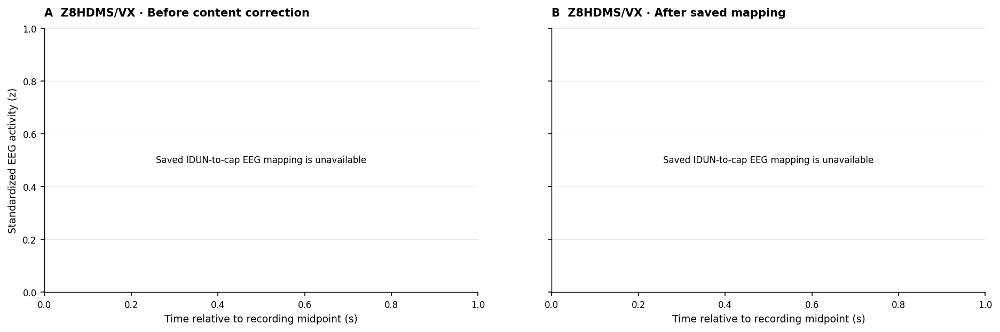

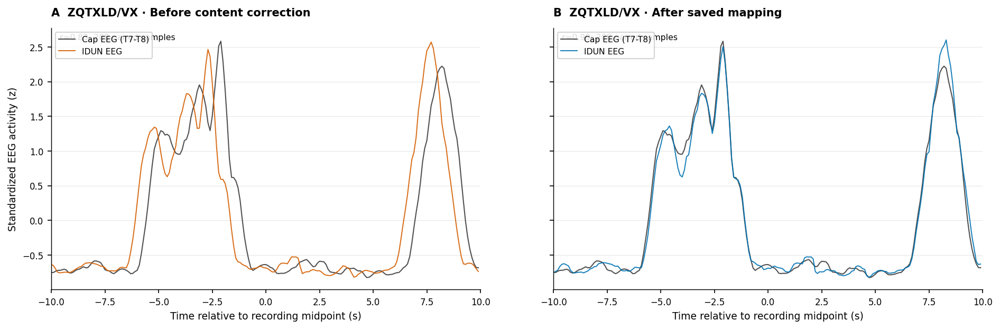

Cap EEG recording midpoint: 3350.4 s (LSL); window length: 20.0 s.
Saved 43 participant EEG figures using a 20-second window.


In [9]:
EEG_WINDOW_SECONDS = 20  # Change the window length here, in seconds, then rerun this cell.

from helpers.sync_quality import idun_lsl_alignment as eeg_alignment

_EEG_FEATURE_CACHE = globals().get('_EEG_FEATURE_CACHE', {})


def load_eeg_example(config, record, duration_s=20):
    """Compare the saved-prior and final IDUN timing at the cap recording midpoint."""
    metadata = {key: record.get(key, '') for key in ('project', 'pid', 'visit')}
    try:
        if not is_true(record.get('usable')):
            raise ValueError('Saved IDUN-to-cap EEG mapping is unavailable')
        a, b = number(record.get('intercept_s')), number(record.get('scale'))
        origin, prior = number(record.get('idun_raw_time_origin_unix_s')), number(record.get('coarse_prior_offset_s'))
        low, high = number(record.get('cap_lsl_start_s')), number(record.get('cap_lsl_end_s'))
        if not all(np.isfinite([a, b, origin, prior, low, high])) or b <= 0 or high <= low:
            raise ValueError('Saved mapping coefficients or recording bounds are invalid')
        center, duration_s = (low + high) / 2, min(float(duration_s), high - low)
        start, end = center - duration_s / 2, center + duration_s / 2
        if start > a + b * number(record.get('idun_raw_duration_s')):
            raise ValueError('IDUN recording ends before the cap EEG midpoint window')
        if end < a:
            raise ValueError('IDUN recording starts after the cap EEG midpoint window')
        feature = str(record['selected_cap_feature'])
        raw_path = idun_raw_source_path(config, record['raw_csv_path'])
        xdf_path = processed_xdf_path(record)
        stream_name = config.value('modalities', 'cap_eeg_stream_name')
        key = (str(raw_path), raw_path.stat().st_mtime_ns, str(xdf_path), xdf_path.stat().st_mtime_ns,
               stream_name, feature, prior)
        if key not in _EEG_FEATURE_CACHE:
            raw = eeg_alignment._read_idun_raw(raw_path)
            cap_times, cap_values, labels = eeg_alignment._load_cap_eeg(xdf_path, stream_name)
            cap_signal = eeg_alignment._cap_feature(
                cap_values, {label: i for i, label in enumerate(labels)}, eeg_alignment.CAP_FEATURES[feature])
            if cap_signal is None:
                raise ValueError('The saved cap EEG channel is unavailable')
            raw_times = raw['timestamp'].to_numpy(float)
            prior_times = raw_times + prior
            # Reproduce the original full-overlap feature grid and preprocessing.
            base_grid = np.arange(max(prior_times[0], cap_times[0]) + 3,
                                  min(prior_times[-1], cap_times[-1]) - 3, 1 / 50)
            envelopes = []
            for times, values in ((prior_times, raw['ch1'].to_numpy(float)), (cap_times, cap_signal)):
                values = np.interp(base_grid, times, values)
                envelope = eeg_alignment._activity_envelope(values, base_hz=50, feature_hz=10)
                if envelope is None:
                    raise ValueError('Too few valid EEG samples to calculate the activity envelope')
                envelopes.append(envelope)
            _EEG_FEATURE_CACHE[key] = (base_grid[::5], *envelopes)
        feature_times, idun_envelope, cap_envelope = _EEG_FEATURE_CACHE[key]
        grid = np.arange(start, end, 1 / 10)
        cap = pupil_interpolate(feature_times, cap_envelope, grid, max_gap_s=.15)
        before = pupil_interpolate(feature_times, idun_envelope, grid, max_gap_s=.15)
        after_times = a + b * (feature_times - prior - origin)
        after = pupil_interpolate(after_times, idun_envelope, grid, max_gap_s=.15)
        if np.isfinite(cap).sum() < 2 or np.isfinite(after).sum() < 2:
            raise ValueError('Too few valid EEG samples in the midpoint excerpt')
        cap_mean, cap_std = np.nanmean(cap), np.nanstd(cap)
        pooled = np.concatenate([before, after])
        idun_mean, idun_std = np.nanmean(pooled), np.nanstd(pooled)
        if cap_std <= 0 or idun_std <= 0:
            raise ValueError('Midpoint excerpt has no amplitude variation')
        return {'available': True, **metadata, 'cap_feature': feature,
                'start_lsl_s': start, 'end_lsl_s': end, 'midpoint_lsl_s': center, 'sampling_hz': 10,
                'center_rule': 'midpoint of saved cap EEG recording bounds',
                'before_time_rule': 'idun_timestamp + coarse_prior_offset_s',
                'after_time_rule': 'intercept_s + scale * (idun_timestamp - idun_raw_time_origin_unix_s)',
                'intercept_s': a, 'scale': b, 'coarse_prior_offset_s': prior,
                'idun_raw_time_origin_unix_s': origin, 'native_idun_source': str(raw_path),
                'processed_xdf_source': str(xdf_path), 'cap_stream_name': stream_name,
                'signal_rule': 'Step 05 full-overlap 50 Hz grid; 2 s centering; 10 scaled-MAD clipping; 0.5 s RMS; 10 Hz output',
                'amplitude_rule': 'separate cap/IDUN standardization; both IDUN curves share one mean/std',
                'time_from_midpoint_s': grid - center, 'cap_eeg_z': (cap - cap_mean) / cap_std,
                'idun_before_z': (before - idun_mean) / idun_std, 'idun_after_z': (after - idun_mean) / idun_std,
                'correlation_before': pupil_correlation(cap, before),
                'correlation_after': pupil_correlation(cap, after)}
    except (OSError, ValueError, KeyError, TypeError, EOFError) as error:
        return {'available': False, **metadata, 'reason': f'{type(error).__name__}: {error}'}


def plot_eeg_example(excerpt):
    with plt.rc_context(plot_style):
        fig, axs = plt.subplots(1, 2, figsize=(13.2, 5), sharex=True, sharey=True)
        fig.subplots_adjust(left=.08, right=.97, bottom=.22, top=.88, wspace=.17)
        for col, state in enumerate(['before', 'after']):
            ax = axs[col]
            title = f"{chr(65 + col)}  {excerpt['pid']}/{excerpt['visit']} · {'Before content correction' if state == 'before' else 'After saved mapping'}"
            plot_panel(ax, title, 'Time relative to recording midpoint (s)',
                       'Standardized EEG activity (z)' if col == 0 else '')
            if not excerpt['available']:
                ax.text(.5, .5, excerpt['reason'].split(': ', 1)[-1], transform=ax.transAxes,
                        ha='center', va='center', fontsize=8, wrap=True)
                continue
            half_window = (excerpt['end_lsl_s'] - excerpt['start_lsl_s']) / 2
            ax.set_xlim(-half_window, half_window)
            times = excerpt['time_from_midpoint_s']
            ax.plot(times, excerpt['cap_eeg_z'], color='#333333', lw=1, alpha=.85,
                    label=f"Cap EEG ({excerpt['cap_feature']})")
            ax.plot(times, excerpt[f'idun_{state}_z'], color=plot_colors[state], lw=.95, alpha=.9, label='IDUN EEG')
            corr = excerpt[f'correlation_{state}']
            rlabel = f"r={corr['r']:.2f}" if np.isfinite(corr['r']) else 'r unavailable'
            ax.text(.02, .98, f"{rlabel}; {corr['paired_samples']} paired samples",
                    transform=ax.transAxes, va='top', fontsize=7.5)
            ax.legend(loc='best', fontsize=7.5, framealpha=.85)
        return fig


if not np.isfinite(EEG_WINDOW_SECONDS) or EEG_WINDOW_SECONDS <= 0:
    raise ValueError('EEG_WINDOW_SECONDS must be a positive number.')

EEG_EXCERPTS = []
EEG_FIGURE_PATHS = []
eeg_figure_dir = OUTPUT_DIR / '04_eeg_alignment'
eeg_figure_dir.mkdir(parents=True, exist_ok=True)
for _, mapping in QC_TABLES['idun_lsl_alignment_csv'].sort_values(['pid', 'visit']).iterrows():
    excerpt = load_eeg_example(CONFIG, mapping, duration_s=EEG_WINDOW_SECONDS)
    EEG_EXCERPTS.append(excerpt)
    name = f"{excerpt['pid']}_{excerpt['visit']}"
    figure = plot_eeg_example(excerpt)
    for extension in ('png', 'svg'):
        figure.savefig(eeg_figure_dir / f'{name}.{extension}', dpi=150, bbox_inches='tight')
    plt.close(figure)
    path = eeg_figure_dir / f'{name}.png'
    EEG_FIGURE_PATHS.append(path)
    display(Image(filename=str(path), width=1300))
    if excerpt['available']:
        print(f"Cap EEG recording midpoint: {excerpt['midpoint_lsl_s']:.1f} s (LSL); window length: {excerpt['end_lsl_s'] - excerpt['start_lsl_s']:.1f} s.")

(OUTPUT_DIR / 'eeg_examples.json').write_text(
    json.dumps(json_values(EEG_EXCERPTS), ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
print(f'Saved {len(EEG_FIGURE_PATHS)} participant EEG figures using a {EEG_WINDOW_SECONDS:g}-second window.')
